In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.20


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle


import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import proplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install proplot==0.9.7
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS import predict_T_from_proxyObs, predict_RI_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

0.1.2


# Cosmetic settings

In [3]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [157]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.
    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    term = ((1 - b) / (y - b))**v - 1
    x = x0 - (np.log(term) / k)
    return x

In [7]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':4,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren5 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren2 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':2, 
    'fGDGT_cren':2,
    'reported_1292_iso':2,
    'fGDGT_cren_prime':2,
    'reported_1292_iso2':2,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren3 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':3, 
    'fGDGT_cren':3,
    'reported_1292_iso':3,
    'fGDGT_cren_prime':3,
    'reported_1292_iso2':3,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


# Set local path

In [8]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app


In [9]:
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'combined_coretop_culture_mesocosm_rev20260210.csv'
combined_df_raw = pd.read_csv(os.path.join(fpath,fname))
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,weighted_tex,...,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.5327,-86.7852,-1.625,-86.875,2288.0,22.520248,23.409010,5.318187,0.602873,2.026197,...,0.601579,0.063068,13.176591,2025.0,Coretop,False,True,True,True,True
1,-3.9690,-81.3100,-3.875,-81.375,1024.0,21.319408,22.386110,4.969550,0.599447,2.061695,...,0.665086,0.052155,4.880708,2025.0,Coretop,False,True,True,True,True
2,-3.5830,-81.1650,-3.625,-81.125,381.0,22.093159,23.418110,4.208444,0.617192,2.050975,...,0.648727,0.052215,4.408430,2025.0,Coretop,False,True,True,True,True
3,-3.2237,-82.9142,-3.125,-82.875,2949.0,20.624901,22.126291,6.493748,0.605147,2.083571,...,0.625100,0.067842,6.872267,2025.0,Coretop,False,True,True,True,True
4,-3.5975,-83.9632,-3.625,-83.875,3224.0,21.165697,22.478001,6.708450,0.588670,1.978224,...,0.577596,0.063600,8.432598,2025.0,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.000000,25.000000,NaN,0.449778,1.725123,...,0.733745,0.018226,2.629108,2007.0,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.000000,32.000000,NaN,0.683519,2.269506,...,0.674419,0.066023,3.553719,2007.0,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.000000,34.000000,NaN,0.606766,1.947046,...,0.855920,0.015506,2.318038,2007.0,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.000000,36.000000,NaN,0.813041,2.414045,...,0.943144,0.031926,2.396907,2007.0,Mesocosm,False,True,True,True,True


# PhanTEX Analysis

In [10]:
# Paleo-data plotting
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001_extendedRR_121025.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df = PhanAlk_df.rename(columns={'ProxyValue':'Uk37'})
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35703,NaN,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35704,NaN,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35705,NaN,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35706,NaN,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025


In [11]:
# PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
# PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
#                                         'GDGT0':'fGDGT_0',
#                                         'GDGT1':'fGDGT_1',
#                                         'GDGT2':'fGDGT_2',
#                                         'GDGT3':'fGDGT_3',
#                                         'Cren':'fGDGT_cren',
#                                         'Crenisomer':'fGDGT_cren_prime'})
# PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)
# PhanTEX_df['SampleID'] = [f'PhanTEX_RR{i:04d}' for i in range(len(PhanTEX_df))]

# features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
# sum_allGDGTs = PhanTEX_df[features].sum(axis=1)
# for feat in features:
#     PhanTEX_df[feat] = PhanTEX_df[feat] / sum_allGDGTs
# PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['ringIndex_cren3'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_revised_cren3.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI_cren3'] = PhanTEX_df['ringIndex_cren3'] / 3
# PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

# PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
# PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
# PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')

# detector = MahalanobisOutlierDetector(['TEX86','scaledRI_cren3'], confidence=0.9)
# detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
#         (combined_df_raw['datatype'] == 'coretop') 
#         & (combined_df_raw['gdgt23ratio'] <= 5)])
# PhanTEX_df[f'TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)
# # Plate reconstructions

# import pygplates

# rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
# rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

# poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
# static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

# from tqdm import tqdm

# start_time = time.time()

# PhanTEX_df['paleolat'] = np.nan
# PhanTEX_df['paleolon'] = np.nan

# for i in tqdm(range(len(PhanTEX_df.ModLat))):
#     if np.isnan(PhanTEX_df.Age.iloc[i]):
#         continue
#     else:
#         point = pygplates.PointOnSphere(float(PhanTEX_df.ModLat.iloc[i]),float(PhanTEX_df.ModLon.iloc[i]))
#         point_feature = pygplates.Feature()
#         point_feature.set_geometry(point)

#         #Assign a point into an associated plate based on modern-day location, rotation files, etc.
#         partitioned_point_features = pygplates.partition_into_plates(static_polygons,
#                                                                 rotation_model,
#                                                                 point_feature) 



#         # Reconstruct the points to Age
#         reconstructed_point_features = []
#         pygplates.reconstruct(partitioned_point_features,
#                                 rotation_model,
#                                 reconstructed_point_features,
#                                 PhanTEX_df.Age.iloc[i])

#         point = reconstructed_point_features[0].get_reconstructed_geometry()
#         latitude, longitude = point.to_lat_lon()

#         PhanTEX_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
#         PhanTEX_df.paleolon.iloc[i] = np.round(longitude,decimals=5)


# print("%.4f seconds" % (time.time() - start_time))
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_df.to_csv(os.path.join(fpath,'PhanTEX_v001_modified_032626.csv'),index=False)

In [12]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanTEX_v001_modified_032626.csv'
PhanTEX_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,scaledRI,ringIndex_cren3,scaledRI_cren3,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,TEXRI_cren3_mahalDist_low23ratio_outliers_manual,paleolat,paleolon
0,PhanTEX_RR0000,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.650,...,0.673188,2.112658,0.704219,2.975410,30.333373,28.061152,28.043613,False,17.35493,29.48749
1,PhanTEX_RR0001,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.650,...,0.669096,2.094197,0.698066,2.711864,32.086507,29.491964,28.939558,False,17.34220,29.48924
2,PhanTEX_RR0002,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.650,...,0.698053,2.177102,0.725701,2.599119,30.764599,28.413095,28.266512,False,17.32728,29.49129
3,PhanTEX_RR0003,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.650,...,0.719252,2.234005,0.744668,3.118881,31.479751,28.996763,28.632522,False,17.31416,29.49309
4,PhanTEX_RR0004,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.650,...,0.656540,2.064283,0.688094,3.213920,30.576403,28.259500,28.169440,False,17.30117,29.49487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8233,PhanTEX_RR8233,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,0.482939,1.494609,0.498203,9.062967,10.995029,12.278255,15.800974,False,-36.41225,164.56487
8234,PhanTEX_RR8234,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,0.480985,1.483324,0.494441,8.565907,8.553676,10.285757,13.823910,False,-36.41307,164.56493
8235,PhanTEX_RR8235,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,0.486249,1.497869,0.499290,8.510049,9.615921,11.152704,14.700356,False,-36.41691,164.56520
8236,PhanTEX_RR8236,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,0.521183,1.606250,0.535417,8.848661,13.881473,14.634013,17.980449,False,-36.41954,164.56539


In [13]:
### Regression dataset compilation
fpath = fr'{local_github_path}/data/spreadsheets'
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCren,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,t_sf2tc_avg,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014931,0.026003,0.018622,0.012717,0.014819,-1.636017,1.761114,1.533491,1.647303,1.874926
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.023083,0.041645,0.029270,0.019371,0.024862,-1.586854,1.575668,1.421365,1.498516,1.652819
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015386,0.027329,0.019367,0.012997,0.015979,-1.692642,1.648903,1.464398,1.556650,1.741155
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012017,0.022152,0.015395,0.009990,0.013538,-1.498910,1.547138,1.425926,1.486532,1.607744
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.012829,0.022799,0.016152,0.010835,0.013332,-1.651191,1.604469,1.425698,1.515084,1.693855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,0.170341,0.324512,0.221731,0.139506,0.208941,22.000000,1.673550,1.594122,1.633836,1.713264
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.182046,0.341748,0.235280,0.150106,0.217802,25.000000,1.793452,1.683386,1.738419,1.848485
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.212344,0.333060,0.252582,0.188200,0.177191,32.000000,2.269506,1.779857,2.024682,2.514331
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.434933,0.717056,0.528974,0.378508,0.444013,36.000000,2.414045,1.989968,2.202006,2.626083


In [14]:
import numpy as np
from scipy.linalg import inv

class MahalanobisDistance:
    def __init__(self):
        self.mean_ = None
        self.cov_inv_ = None
    
    def fit(self, X):
        """Fit the model on reference data"""
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.cov_inv_ = inv(cov)
        return self
    
    def distance(self, X):
        """Compute Mahalanobis distance for new data"""
        diff = X - self.mean_
        distances = np.sqrt(np.sum(diff @ self.cov_inv_ * diff, axis=1))
        return distances

X_train = gridded_combined_df[['ringIndex_cren3','TEX86']].dropna().to_numpy()
# Usage
md_model = MahalanobisDistance()
md_model.fit(X_train)  # Fit on Dataset 1

# Apply to Dataset 2
X_test = PhanTEX_df[['ringIndex_cren3','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to PhanTEX_df
PhanTEX_df['mahalanobis_distance'] = np.nan
PhanTEX_df.loc[PhanTEX_df[['ringIndex_cren3','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
PhanTEX_df

Distances: [1.37962223 1.70478341 1.36441818 ... 0.69809814 0.52717603 0.56260218]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,ringIndex_cren3,scaledRI_cren3,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,TEXRI_cren3_mahalDist_low23ratio_outliers_manual,paleolat,paleolon,mahalanobis_distance
0,PhanTEX_RR0000,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.650,...,2.112658,0.704219,2.975410,30.333373,28.061152,28.043613,False,17.35493,29.48749,1.379622
1,PhanTEX_RR0001,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.650,...,2.094197,0.698066,2.711864,32.086507,29.491964,28.939558,False,17.34220,29.48924,1.704783
2,PhanTEX_RR0002,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.650,...,2.177102,0.725701,2.599119,30.764599,28.413095,28.266512,False,17.32728,29.49129,1.364418
3,PhanTEX_RR0003,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.650,...,2.234005,0.744668,3.118881,31.479751,28.996763,28.632522,False,17.31416,29.49309,1.437557
4,PhanTEX_RR0004,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.650,...,2.064283,0.688094,3.213920,30.576403,28.259500,28.169440,False,17.30117,29.49487,1.536365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8233,PhanTEX_RR8233,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,1.494609,0.498203,9.062967,10.995029,12.278255,15.800974,False,-36.41225,164.56487,0.798464
8234,PhanTEX_RR8234,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,1.483324,0.494441,8.565907,8.553676,10.285757,13.823910,False,-36.41307,164.56493,0.738349
8235,PhanTEX_RR8235,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,1.497869,0.499290,8.510049,9.615921,11.152704,14.700356,False,-36.41691,164.56520,0.698098
8236,PhanTEX_RR8236,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,1.606250,0.535417,8.848661,13.881473,14.634013,17.980449,False,-36.41954,164.56539,0.527176


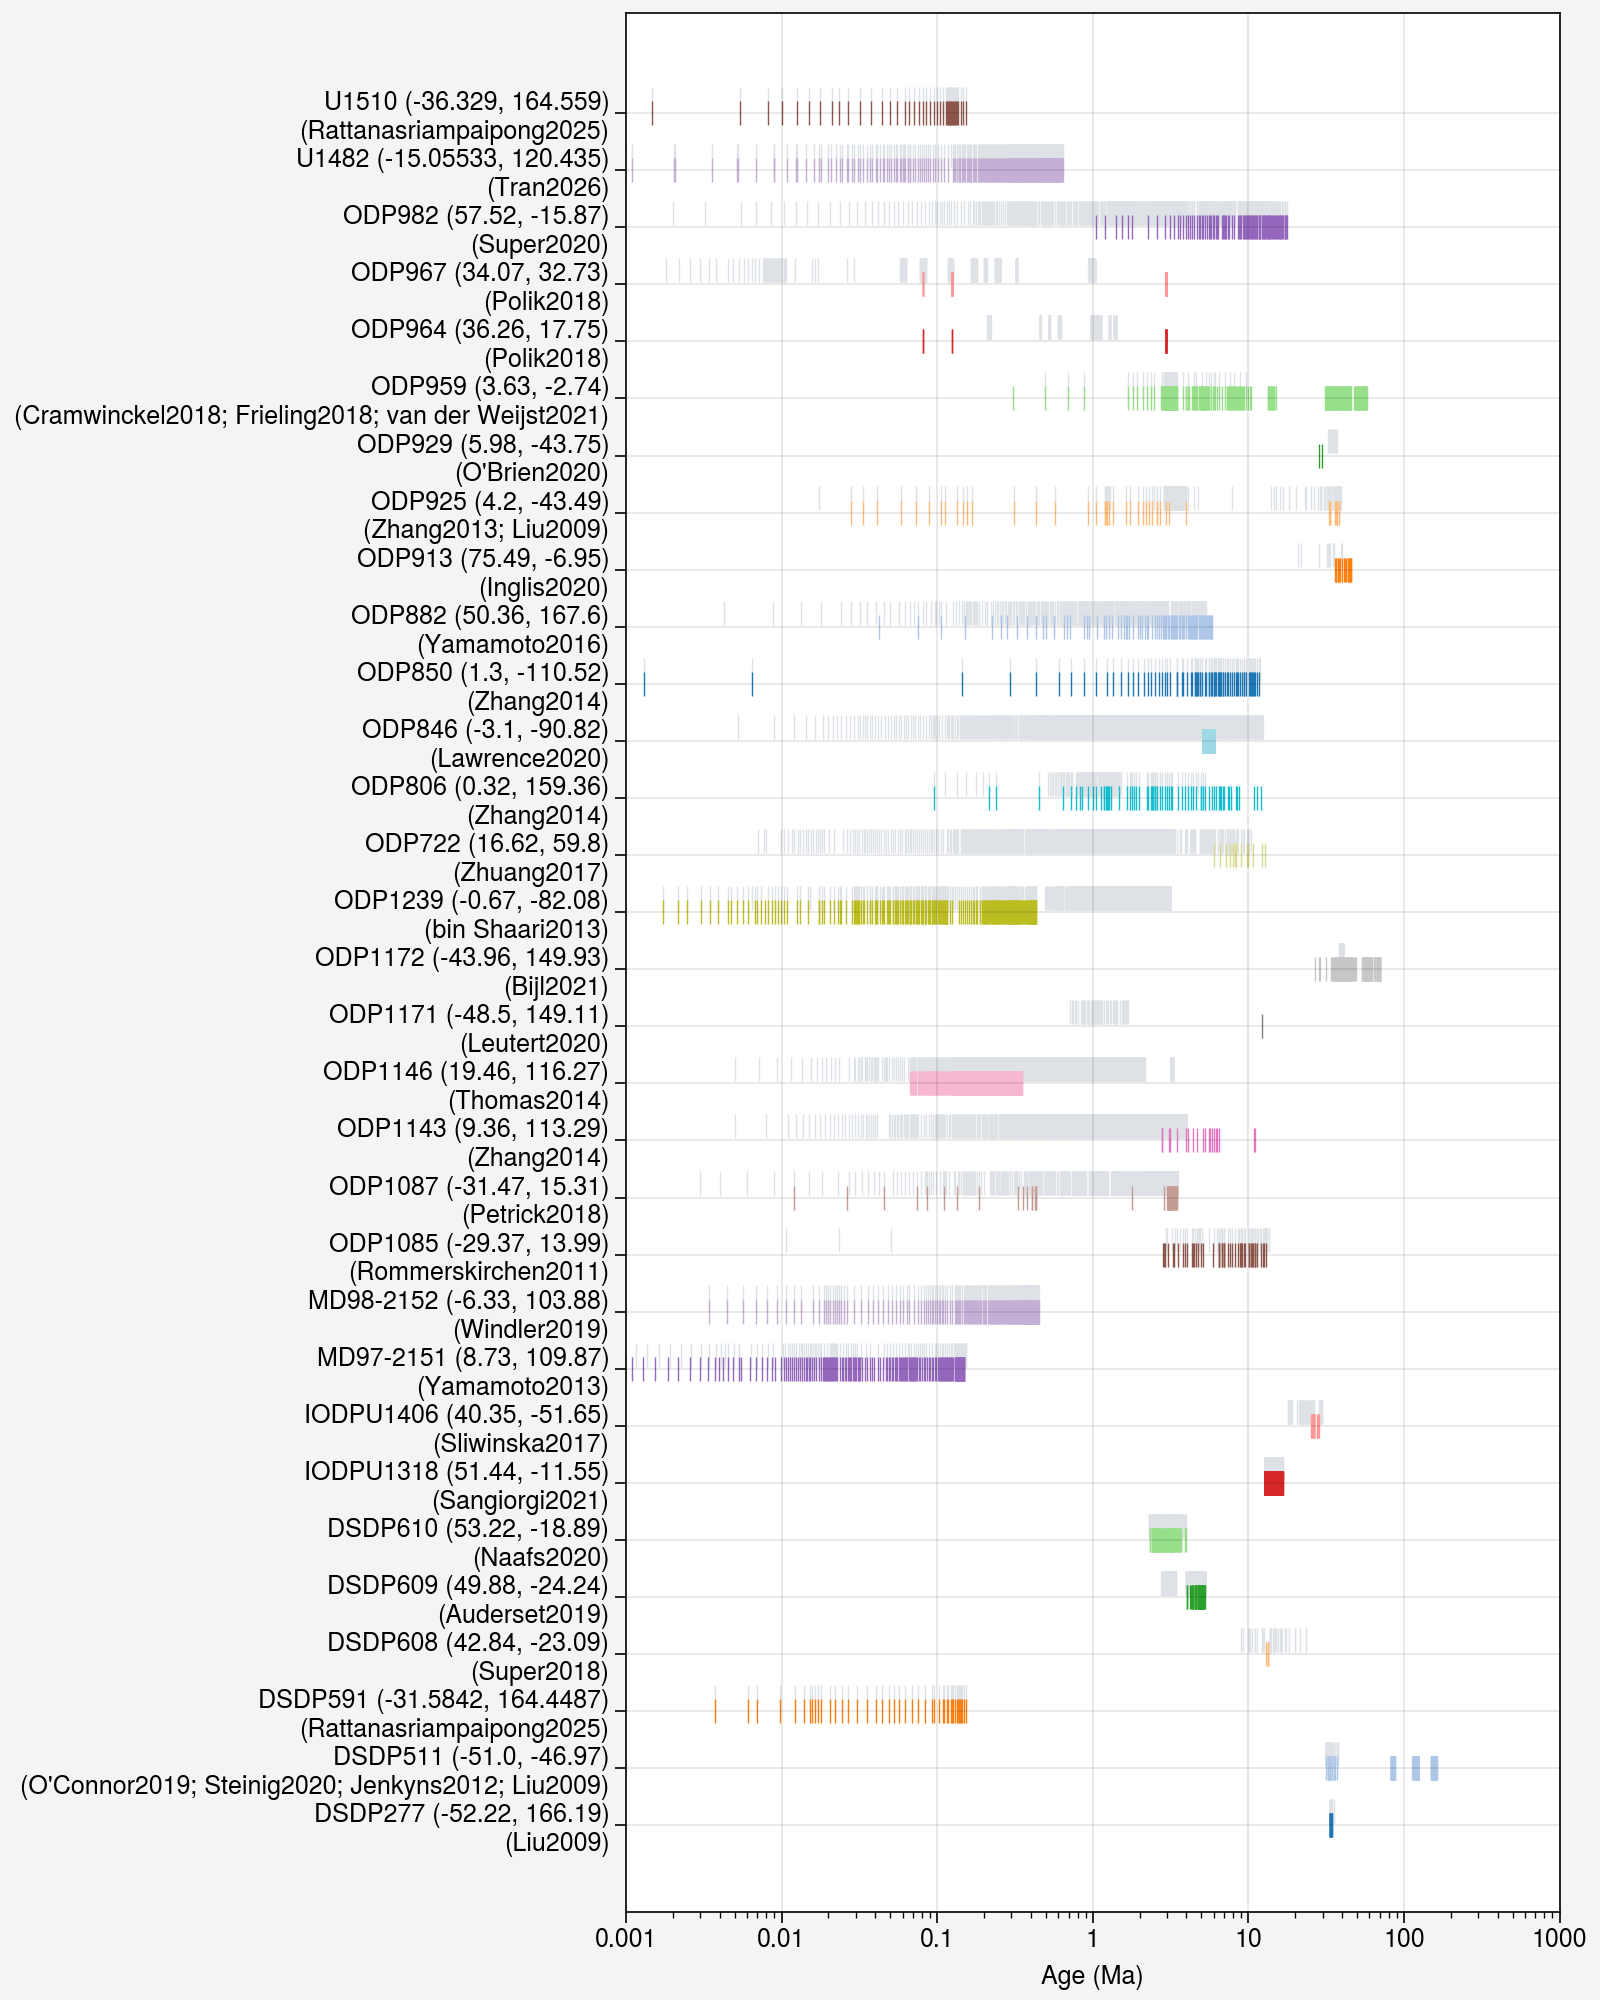

In [15]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=12, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [17]:
PhanAlk_GIG_df = PhanAlk_df[PhanAlk_df['SiteName'].isin(['MD97-2151','MD98-2152','ODP1239','U1510','U1482','DSDP591'])].reset_index(drop=True)
PhanAlk_GIG_df['predSST'] = bsl.predict_sst(PhanAlk_GIG_df['Uk37'],prior_std=5).percentile(50)

100%|██████████| 500/500 [00:19<00:00, 25.35it/s]


In [18]:
bsl.predict_sst(PhanAlk_GIG_df['Uk37'],prior_std=10).percentile([16,50,84])

100%|██████████| 500/500 [00:19<00:00, 25.55it/s]


array([[27.3       , 27.3       , 27.3       ],
       [26.8       , 26.8       , 26.8       ],
       [26.6       , 26.6       , 26.6       ],
       ...,
       [15.87412563, 15.87412563, 15.87412563],
       [17.2017855 , 17.2017855 , 17.2017855 ],
       [15.80650606, 15.80650606, 15.80650606]])

In [19]:
# PhanTEX_GIG_df = PhanTEX_df[
#     PhanTEX_df['SiteName'].isin(['MD98-2152', 'U1482']) #'MD97-2151', 'MD98-2152', 'ODP1239', 'U1510', 'U1482', 'DSDP591'
# ].reset_index(drop=True)

# # ── predict BAYSPAR subT and SST for GIG sites ────────────────────────────
# temp_subT_df_list = []
# temp_SST_df_list  = []

# for site_name, group in tqdm(PhanTEX_GIG_df.groupby('SiteName')):
#     tex  = group['TEX86']
#     lat  = group['paleolat'].iloc[0]
#     lon  = group['paleolon'].iloc[0]
#     sids = group['SampleID'].values   # .values avoids index misalignment

#     temp_subT_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_std=10, temptype='subt',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_subT_df_list.append(pd.DataFrame({
#         'SampleID':         sids,
#         'BAYSPAR_subT_p5':  temp_subT_pred[:, 0],
#         'BAYSPAR_subT_p16': temp_subT_pred[:, 2],
#         'BAYSPAR_subT_p25': temp_subT_pred[:, 3],
#         'BAYSPAR_subT':     temp_subT_pred[:, 4],
#         'BAYSPAR_subT_p75': temp_subT_pred[:, 5],
#         'BAYSPAR_subT_p84': temp_subT_pred[:, 6],
#         'BAYSPAR_subT_p95': temp_subT_pred[:, 8],
#     }))

#     temp_SST_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_std=10, temptype='sst',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_SST_df_list.append(pd.DataFrame({
#         'SampleID':        sids,
#         'BAYSPAR_SST_p5':  temp_SST_pred[:, 0],
#         'BAYSPAR_SST_p16': temp_SST_pred[:, 2],
#         'BAYSPAR_SST_p25': temp_SST_pred[:, 3],
#         'BAYSPAR_SST':     temp_SST_pred[:, 4],
#         'BAYSPAR_SST_p75': temp_SST_pred[:, 5],
#         'BAYSPAR_SST_p84': temp_SST_pred[:, 6],
#         'BAYSPAR_SST_p95': temp_SST_pred[:, 8],
#     }))


# BAYSPAR_subT_df = (pd.concat(temp_subT_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))
# BAYSPAR_SST_df  = (pd.concat(temp_SST_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))


# # ── sanity check before merging ───────────────────────────────────────────
# assert PhanTEX_GIG_df['SampleID'].duplicated().sum() == 0, "GIG base has dupes"
# assert BAYSPAR_subT_df['SampleID'].duplicated().sum() == 0, "subT df has dupes"
# assert BAYSPAR_SST_df['SampleID'].duplicated().sum() == 0,  "SST df has dupes"

# # ── merge and save ────────────────────────────────────────────────────────
# PhanTEX_GIG_df = (PhanTEX_GIG_df
#                   .merge(BAYSPAR_subT_df, on='SampleID', how='left')
#                   .merge(BAYSPAR_SST_df,  on='SampleID', how='left'))
    
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_GIG_df.to_parquet(os.path.join(fpath, 'PhanTEX_GIG_df.parquet'), index=False)
# PhanTEX_GIG_df.to_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'), index=False)

In [20]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
PhanTEX_GIG_df = pd.read_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'))

# drop _x columns (original NaN placeholders) and rename _y to clean names
x_cols = [c for c in PhanTEX_GIG_df.columns if c.endswith('_x')]
PhanTEX_GIG_df = PhanTEX_GIG_df.drop(columns=x_cols)
PhanTEX_GIG_df = PhanTEX_GIG_df.rename(columns=lambda c: c.removesuffix('_y'))
PhanTEX_GIG_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,BAYSPAR_subT_p75,BAYSPAR_subT_p84,BAYSPAR_subT_p95,BAYSPAR_SST_p5,BAYSPAR_SST_p16,BAYSPAR_SST_p25,BAYSPAR_SST,BAYSPAR_SST_p75,BAYSPAR_SST_p84,BAYSPAR_SST_p95
0,PhanTEX_RR3582,MD98-2152,NaN,0.105,NaN,NaN,NaN,NaN,in,-6.33000,...,26.594025,27.551836,29.558110,24.321511,25.865994,26.603534,28.096132,29.652976,30.289124,31.767150
1,PhanTEX_RR3583,MD98-2152,NaN,0.530,NaN,NaN,NaN,NaN,in,-6.33000,...,26.567674,27.519429,29.312759,24.352099,25.904384,26.585880,28.108918,29.558293,30.302088,31.873499
2,PhanTEX_RR3584,MD98-2152,NaN,0.710,NaN,NaN,NaN,NaN,in,-6.33000,...,26.815904,27.738952,29.602042,24.477903,26.009736,26.789892,28.269526,29.744164,30.534266,31.985486
3,PhanTEX_RR3585,MD98-2152,NaN,0.910,NaN,NaN,NaN,NaN,in,-6.33000,...,26.687079,27.656390,29.454077,24.446969,25.905867,26.555939,28.046476,29.672916,30.351845,31.794643
4,PhanTEX_RR3586,MD98-2152,NaN,1.110,NaN,NaN,NaN,NaN,in,-6.33000,...,26.559267,27.520108,29.425631,24.435511,25.933723,26.643764,28.123849,29.697105,30.448800,31.855965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,PhanTEX_RR8144,U1482,NaN,NaN,NaN,34.61,NaN,NaN,in,-15.05533,...,29.133246,30.884810,34.999900,21.609554,24.048575,25.292339,28.023317,31.085261,32.580718,36.196197
455,PhanTEX_RR8145,U1482,NaN,NaN,NaN,34.67,NaN,NaN,in,-15.05533,...,28.778817,30.546801,34.439408,21.227238,23.804236,25.053855,27.825522,30.748265,32.330265,35.916747
456,PhanTEX_RR8146,U1482,NaN,NaN,NaN,34.73,NaN,NaN,in,-15.05533,...,28.862563,30.659303,34.619580,21.373905,23.844130,25.060087,27.810799,30.806866,32.290607,35.809176
457,PhanTEX_RR8147,U1482,NaN,NaN,NaN,34.79,NaN,NaN,in,-15.05533,...,26.741190,28.448234,32.153020,19.589187,22.058314,23.285107,25.958058,28.773076,30.252354,33.523877


In [21]:
display_function_signature(predict_T_from_proxyObs)

```python
predict_T_from_proxyObs(
    proxyObs=None,
    prior_mu_t=None,
    prior_sigma_t=None,
    fwd_posterior_name=None,
    proxy_name=None,
    scaledRI=None,
    fwd_posterior=None,
    temptype=None,
    site_name=None,
    predictors=None,
    config=None,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    seed=42,
    constraint_type=unconstrained,
    min_temp=None,
    threads_per_chain=None,
    save_results=False,
    filename_tag=None
)
```

In [22]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [23]:
display_function_signature(predict_T_from_proxyObs)

```python
predict_T_from_proxyObs(
    proxyObs=None,
    prior_mu_t=None,
    prior_sigma_t=None,
    fwd_posterior_name=None,
    proxy_name=None,
    scaledRI=None,
    fwd_posterior=None,
    temptype=None,
    site_name=None,
    predictors=None,
    config=None,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    seed=42,
    constraint_type=unconstrained,
    min_temp=None,
    threads_per_chain=None,
    save_results=False,
    filename_tag=None
)
```

In [24]:
# from TEXAS.data.builder import InvTConfig, build_invT_inputData

# siteName_grouped = PhanTEX_GIG_df.groupby('SiteName')
# temp_params = ['SST','thermoT'] # or thermoT 'SST',
# temp_types = ['sst','thermoT'] # or thermoT 'sst',
# date_tag = '032326'
# y_param = 'scaledRI_cren3'

# no3_thershold_dict = {
#     'thermoT':'1.9'
# }

# for i, (temp_param,temp_type) in enumerate(zip(temp_params,temp_types)):
#     for name, group in siteName_grouped:
#         print(name)
#         #######################
#         fwd_post = f"gen_logi_fixed_hier_crtp_univ_priorApprox_{temp_param}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )
        
#         ########################
#         fwd_post = f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             predictors={
#                 'gdgt23ratio':group['gdgt23ratio'].values,
#             },
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )
        
#         ########################
#         modLat = group['ModLat'].iloc[0]
#         modLon = group['ModLon'].iloc[0]
#         modern_no3 = np.atleast_1d(ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat,lon=modLon,method='nearest').values)[0]
        
#         ########################
#         fwd_post = f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             predictors={
#                 'gdgt23ratio':group['gdgt23ratio'].values,
#                 'no3':np.full(len(group), modern_no3),
#             },
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )

In [25]:
siteName_list = PhanTEX_GIG_df['SiteName'].unique()

y_param = 'scaledRI_cren3'
temp_params = ['SST','thermoT']
temp_types = ['sst','thermoT']
date_tag = '032326'
no3_thershold_dict = {
    'thermoT':'1.9'
}
for temp_param, temp_type in zip(temp_params,temp_types):
    for site_name in siteName_list:
        
        idx = PhanTEX_GIG_df[PhanTEX_GIG_df['SiteName']==site_name].index
        
        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_univ_unconstrained_{temp_type}_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}'] = predT_.sel(quantile=0.5).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p84'] = predT_.sel(quantile=0.84).values
        
        ##############################

        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_multiv_unconstrained_{temp_type}_gdgt23ratio_no3_0.0_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r'] = predT_.sel(quantile=0.5).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p84'] = predT_.sel(quantile=0.84).values
        
        ##############################

        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_multiv_unconstrained_{temp_type}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3'] = predT_.sel(quantile=0.5).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_GIG_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p84'] = predT_.sel(quantile=0.84).values
    

In [26]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [27]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [28]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [29]:
url = 'https://www.ncei.noaa.gov/pub/data/paleo/paleocean/indian_ocean/tran2025/tran2025-u1482-bio-sst.txt'
Tran2025_df = pd.read_csv(url,comment='#',delimiter='\t')
Tran2025_df['Age'] = Tran2025_df['age_ka']/1000

In [30]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'U1482_MgCa_SST.xlsx'
Tran2025_BayMG_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='MgCa_Pei2021')
Tran2025_BayMG_df

,Age_ka,Mg_SST
0,1.59,30.5476
1,3.84,30.8152
2,5.71,30.7678
3,7.59,32.2386
4,9.46,31.5254
...,...,...
150,427.76,29.0003
151,432.87,26.9476
152,437.98,26.8391
153,443.09,26.9470


modern NO3 MD98-2152 5.8978076
modern NO3 U1482 2.7273462


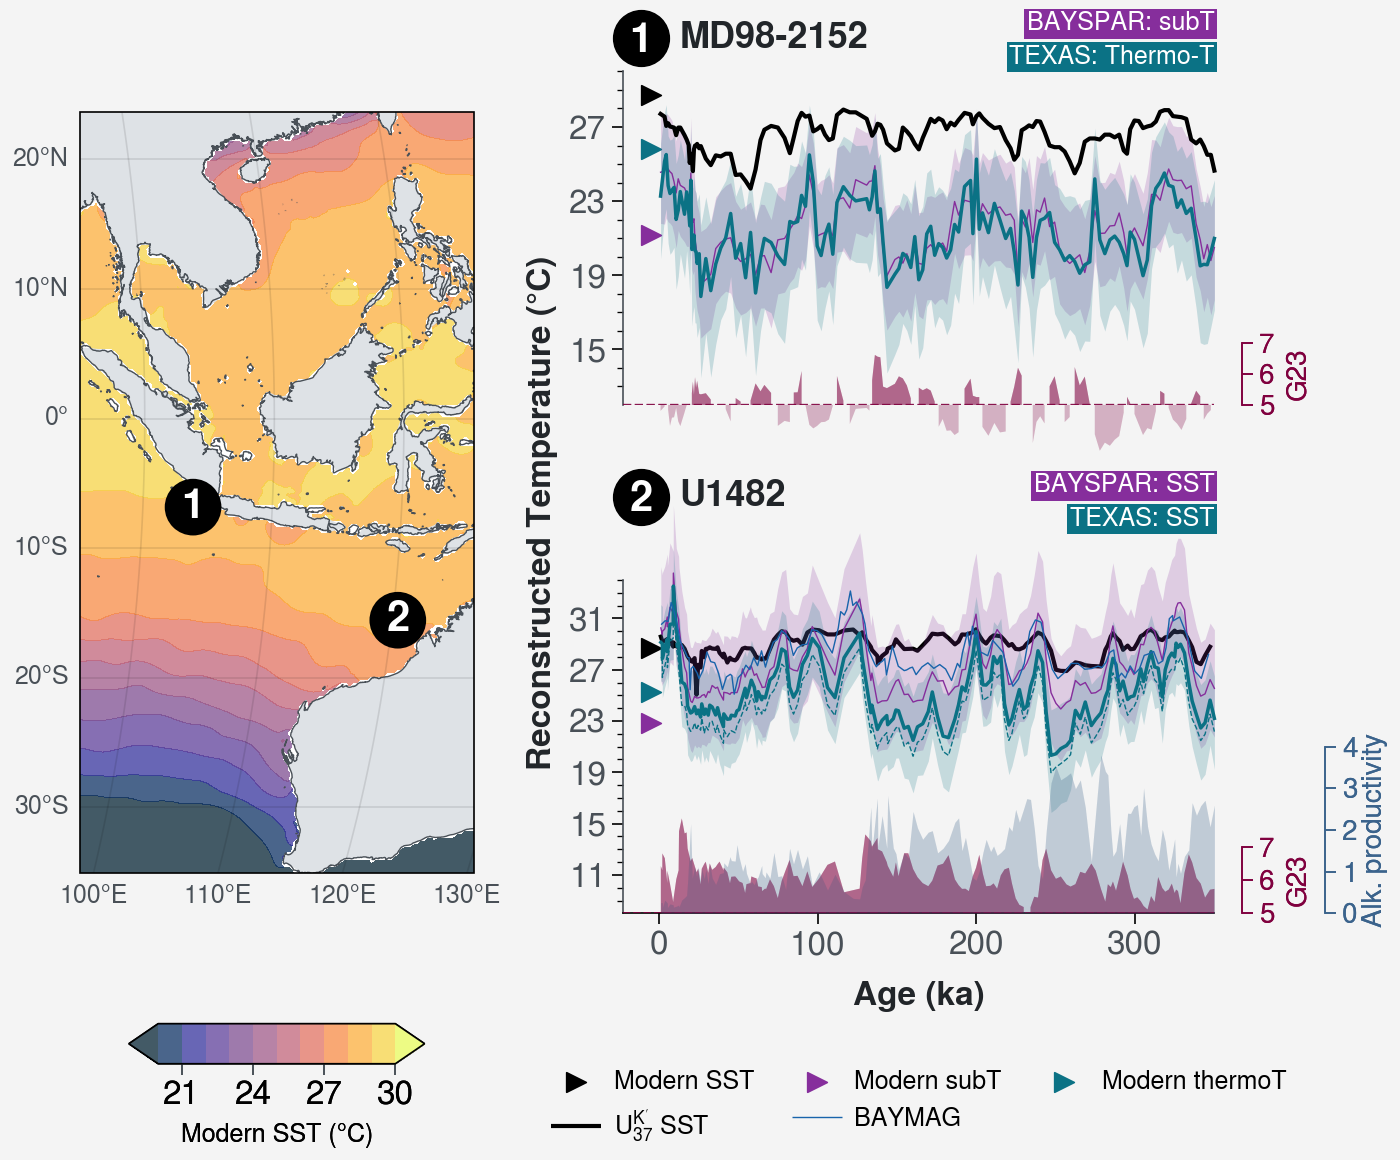

In [434]:
from cartopy import crs as ccrs
from collections import OrderedDict

# ============================================================
# CONTROL PANEL — edit only this section
# ============================================================
T_map = 'SST'
sel_age_limit = 0.351
sel_site_list = [
    # 'MD97-2151',
    'MD98-2152', 
    'U1482',
    # 'DSDP591',
    # 'U1510',
]

site_yparam_dict = {
    'MD97-2151': {
        'params':   ['BAYSPAR_subT',
                     'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'],
        'band_pct': (16, 84),
        'band_params': ['BAYSPAR_subT',
                        'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'],
    },
    'MD98-2152': {
        'params':   ['BAYSPAR_subT',
                     'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'],
        'band_pct': (16, 84),
    },
    'U1482': {
        'params':   ['BAYSPAR_SST',
                     'pred_SST_TEXAS_scaledRI_cren3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r'],
        'band_pct': (16, 84),
        'band_params': ['BAYSPAR_SST',
                        'pred_SST_TEXAS_scaledRI_cren3_Tg23r'],
    },
    'DSDP591': {
        'params':   ['BAYSPAR_subT',
                     'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'],
        'band_pct': (16, 84),
    },
    'U1510': {
        'params':   ['BAYSPAR_subT',
                     'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'],
        'band_pct': (16, 84),
        'band_params': [],
    },
}

# Secondary y-axis config — omit a site to skip twin axis
site_twinx_dict = {
    'MD98-2152': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 7),
        'yaxis_lim':   (5, 15),
        'yticks':      np.arange(5, 7.1, 1),
        'hlines':      [5],
        'hline_style': {'lw': 0.8, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 10,
    },
    'U1482': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 7),
        'yaxis_lim':   (5, 15),
        'yticks':      np.arange(5, 7.1, 1),
        'hlines':      [5],
        'hline_style': {'lw': 0.7, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 0,
    },
    'DSDP591': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 7),
        'yaxis_lim':   (5, 15),
        'yticks':      np.arange(5, 7.1, 1),
        'hlines':      [5],
        'hline_style': {'lw': 0.7, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 0,
    },
}

site_twinx2_dict = {
    'U1482': {
        'col':         'uk37_total',   # ← your actual column name
        'label':       'Alk. productivity',
        'color':       'denim',
        'ydata_lim':   (0, 4),
        'yaxis_lim':   (0, 8),
        'yticks':      np.arange(0, 4.1, 1),
        'hline_style': {'lw': 0.5, 'ls': ':', 'alpha': 0.7},
    },
}

ylim_dict = {
    'MD97-2151': (18, 29),
    'MD98-2152': (12, 30),
    'U1482':     (8, 34),
    'DSDP591':   (6, 30),
    'U1510':     (9, 26),
}

# Map padding
pad_latmax = 30
pad_latmin = 20
pad_lonmin = 5
pad_lonmax = 5

# Figure sizing
height_per_site = 2
legend_space    = 1.8
fig_width       = 7
hspace_base     = 7
hspace_compensate = 0.25   # reduce gap at map→empty boundary

# ============================================================
# LOOKUP DICTS — edit to add new methods
# ============================================================
method_color_dict = {
    'SST_Schouten02':                          ('red9',   '-'),
    'SST_Kim10':                               ('yellow9','-'),
    'BAYSPAR_SST':                             ('grape9', '-'),
    'BAYSPAR_subT':                            ('grape9', '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3':       ('cyan9',   '--'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': ('cyan9',  '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
    'pred_SST_TEXAS_scaledRI_cren3':           ('cyan9',   '--'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     ('cyan9',  '-'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
}

text_annotation_dict = {
    'BAYSPAR: SST': 'BAYSPAR_SST',
    'BAYSPAR: subT': 'BAYSPAR_subT',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3',
}

method_label_dict = {
    'SST_Schouten02':                          'Schouten et al. 2002',
    'SST_Kim10':                               r'TEX$^{H}_{86}$',
    'BAYSPAR_SST':                             'BAYSPAR SST',
    'BAYSPAR_subT':                            'BAYSPAR subT',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS Thermo-T',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS (Thermo-T + G23)',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (Thermo-T + G23 + NO3)',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS SST',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS (SST + G23)',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (SST + G23 + NO3)',
}

# Collapse BAYSPAR/TEXAS variants to single legend entry
# Band entries are built dynamically — no hardcoded band strings needed
legend_label_remap = {
    'BAYSPAR_SST':                             'BAYSPAR',
    'BAYSPAR_subT':                            'BAYSPAR',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3':     'TEXAS',
}

# ============================================================
# DATA PREPARATION
# ============================================================
n_sites       = len(sel_site_list)
site_axs_dict = {site: i + 1 for i, site in enumerate(sel_site_list)}

plot_data = (
    PhanTEX_GIG_df[PhanTEX_GIG_df['Age'] < sel_age_limit]
    [PhanTEX_GIG_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False]
    [(((PhanTEX_GIG_df['TEX86']>0.5)&(PhanTEX_GIG_df['SiteName']=='MD98-2152'))|(PhanTEX_GIG_df['SiteName']!='MD98-2152'))]
    [PhanTEX_GIG_df['gdgt23ratio']<15]
    [PhanTEX_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)
plot_data['SiteName'] = pd.Categorical(
    plot_data['SiteName'], categories=sel_site_list, ordered=True
)

plot_alk_data = (
    PhanAlk_GIG_df[PhanAlk_GIG_df['Age'] < sel_age_limit]
    [PhanAlk_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)

plot_alk_conc_data = (
    Tran2025_df[Tran2025_df['Age'] < sel_age_limit] 
    .reset_index(drop=True)
)

# Auto map extent
site_lats = plot_data.groupby('SiteName')['ModLat'].first()
site_lons = plot_data.groupby('SiteName')['ModLon'].first()
lat_min = max(site_lats.min() - pad_latmin, -90)
lat_max = min(site_lats.max() + pad_latmax,  90)
lon_min = max(site_lons.min() - pad_lonmin, -180)
lon_max = min(site_lons.max() + pad_lonmax,  180)

# ============================================================
# FIGURE SETUP
# ============================================================
map_rows   = max(2, round(n_sites / 2))
array      = [[1 if row < map_rows else 0, row + 2] for row in range(n_sites)]
hratios    = [1] * n_sites
fig_height = height_per_site * n_sites + legend_space

hspace_vals = []
for gap_idx in range(n_sites - 1):
    if gap_idx == map_rows - 1:
        hspace_vals.append(hspace_compensate)
    else:
        hspace_vals.append(hspace_base)

fig, axs = plot.subplots(
    array,
    width=fig_width, height=fig_height,
    proj={1: 'eck3'},
    hspace=hspace_vals,
    wratios=[1, 1.5],
    hratios=hratios,
    share=0,
)

# ============================================================
# MAP PANEL
# ============================================================
ax = axs[0]
ax.format(
    land=True, landcolor='gray3', landzorder=0,
    coast=False, # coastcolor='gray7', coastzorder=1,
    latlabels=True, lonlabels=True, latlines=10, lonlines=10,
    latlim=(lat_min, lat_max),
    lonlim=(lon_min, lon_max),
)
import cartopy.feature as cfeature
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),   # '110m' → '50m' → '10m'
               linewidth=0.5, edgecolor='gray7', zorder=1)

if T_map == 'SST':
    plot_T   = T_da.isel(depth=0).values
    plot_lat = T_da['lat'].values
    plot_lon = T_da['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 1), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
if T_map == 'thermoT':
    plot_T   = ocean_prop_ds['t_sf2tc_avg'].values
    plot_lat = ocean_prop_ds['lat'].values
    plot_lon = ocean_prop_ds['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 2), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
# ============================================================
# MAIN SITE LOOP
# ============================================================
grouped      = plot_data.groupby('SiteName')
legend_items = OrderedDict()

for i, (group_name, group_data) in enumerate(grouped):

    modLat = group_data['ModLat'].unique()[0]
    modLon = group_data['ModLon'].unique()[0]

    # Pre-compute modern reference values
    mod_SST        = T_da.isel(depth=0).sel(lat=modLat, lon=modLon, method='nearest').values
    mod_subT_gamma = subT.sel(lat=modLat, lon=modLon, method='nearest').values
    thermoT        = ocean_prop_ds.sel(lat=modLat, lon=modLon, method='nearest')['t_sf2tc_avg'].values

    print("modern NO3", group_name,
          ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat, lon=modLon, method='nearest').values)

    # --- Map marker + number ---
    # axs[0].plot(modLon, modLat, marker='o', markersize=15,
    #             c='k', mec='w', mew=0.5)
    axs[0].text(modLon, modLat - 0.5, i + 1,
                fontweight='bold', fontsize=15,
                ha='center', va='center', color='white',
                transform=ccrs.PlateCarree(),
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                         edgecolor='none')
                )

    ax = axs[site_axs_dict[group_name]]

    # --- Modern reference markers (legend registered once via setdefault) ---
    h1 = ax.scatter(-5, mod_SST,        marker='>', color='k',                                                s=50)
    h2 = ax.scatter(-5, mod_subT_gamma, marker='>', color=method_color_dict['BAYSPAR_subT'][0],               s=50)
    h3 = ax.scatter(-5, thermoT,        marker='>', color=method_color_dict['pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'][0], s=50)
    legend_items.setdefault('Modern SST',                    h1)
    legend_items.setdefault('Modern subT',   h2)
    legend_items.setdefault('Modern thermoT',                h3)

    # --- Circled number + site label ---
    y_pos = 1.25 if 'U1482' in group_name else 1.1
    ax.scatter(0.06-0.03, y_pos, marker='o', color='k', markersize=400,
               transform=ax.transAxes, clip_on=False, zorder=-1)
    ax.text(0.06-0.03, y_pos - 0.01, i + 1,
            transform=ax.transAxes, fontsize=15, fontweight='bold',
            ha='center', va='center', color='white')
    ax.text(0.125-0.03, y_pos, group_name,
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='left', va='center', color='gray9')
    
    # --- Alkenone ---
    sel_alk_data = plot_alk_data[plot_alk_data['SiteName'] == group_name]
    if not sel_alk_data.empty:
        if group_name != 'U1482':
            h, = ax.plot(sel_alk_data['Age'].values * 1000, sel_alk_data['predSST'].values,
                        color='k', lw=1.5, clip_on=False)
            legend_items.setdefault(u"U$^{K'}_{37}$ SST", h)

    # --- Per-site param config ---
    site_cfg         = site_yparam_dict.get(group_name, {})
    yparam_list_site = site_cfg.get('params', [])
    plo, phi         = site_cfg.get('band_pct', (16, 84))
    band_label_str   = f'P{plo}-P{phi}'
    band_params      = site_cfg.get('band_params', yparam_list_site)

    # STEP 1: detect variants + colors for annotation
    bayspar_variant = None
    texas_variant   = None
    bayspar_color   = None
    texas_color     = None
    for yparam in yparam_list_site:
        if 'BAYSPAR' in yparam:
            bayspar_variant = 'subT' if 'subT' in yparam else 'SST'
            bayspar_color   = method_color_dict[yparam][0]
        if 'TEXAS' in yparam:
            texas_variant = 'Thermo-T' if 'thermo' in yparam.lower() else 'SST'
            texas_color   = method_color_dict[yparam][0]

    # STEP 2: per-panel variant annotation with colored background boxes
    y_pos = 1.32 if 'U1482' in group_name else 1.18
    if bayspar_variant:
        ax.text(1, y_pos, f'BAYSPAR: {bayspar_variant}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=bayspar_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        y_pos -= 0.1
    if texas_variant:
        ax.text(1, y_pos, f'TEXAS: {texas_variant}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=texas_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        
    # STEP 3: plot each parameter
    for j, yparam in enumerate(yparam_list_site):
        plot_age   = group_data['Age'].values * 1000
        plot_TEX86 = group_data[yparam].values

        h, = ax.plot(plot_age, plot_TEX86,
                     ls=method_color_dict[yparam][1],
                     c=method_color_dict[yparam][0],
                     lw=1.25 if 'Tg23r' in yparam else 0.5,
                     clip_on=False)
        leg_label = legend_label_remap.get(yparam, method_label_dict[yparam])
        legend_items.setdefault(leg_label, h)

        if 'BAYSPAR' in yparam and yparam in band_params:
            col  = f'BAYSPAR_subT_p{plo}' if 'subT' in yparam else f'BAYSPAR_SST_p{plo}'
            col2 = f'BAYSPAR_subT_p{phi}' if 'subT' in yparam else f'BAYSPAR_SST_p{phi}'
            hf = ax.fill_between(plot_age, group_data[col], group_data[col2],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0)
            # legend_items.setdefault(f'BAYSPAR | {band_label_str}', hf)

        if 'TEXAS' in yparam and yparam in band_params:
            hf = ax.fill_between(plot_age,
                                 group_data[f'{yparam}_p{plo}'],
                                 group_data[f'{yparam}_p{phi}'],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0)
            # legend_items.setdefault(f'TEXAS | {band_label_str}', hf)

    # STEP 4: optional secondary y-axis
    twin_cfg = site_twinx_dict.get(group_name)
    if twin_cfg is not None:
        ax2 = ax.twinx()

        plot_sec = group_data[twin_cfg['col']].values
        # h_sec, = ax2.plot(plot_age, plot_sec,
        #                   color=twin_cfg['color'], lw=0.5, clip_on=False)
        # legend_items.setdefault(twin_cfg['label'], h_sec)

        ylo, yhi      = twin_cfg['yaxis_lim']
        bottom_offset = twin_cfg.get('bottom_offset', 0)
        ax2.set_ylim(ylo + bottom_offset, yhi)
        ax2.set_yticks(twin_cfg['yticks'])
        ax2.minorticks_off()
        ax2.tick_params(axis='y', labelsize=10,
                        labelcolor=twin_cfg['color'],
                        color=twin_cfg['color'])

        ytick_min, ytick_max = twin_cfg['ydata_lim']
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_position(('outward', 10))
        ax2.spines['right'].set_color(twin_cfg['color'])
        ax2.spines['right'].set_bounds(ytick_min, ytick_max)
        ax2.spines['top'].set_visible(False)

        ax2.yaxis.set_label_text('')
        ax2.yaxis.label.set_visible(False)
        ymid = (ytick_min + ytick_max) / 2
        ax2.text(1.12, ymid, 'G23',
                 transform=ax2.get_yaxis_transform(),
                 fontsize=10, color=twin_cfg['color'],
                 ha='left', va='center', rotation=90)

        hlines = twin_cfg.get('hlines', [])
        if isinstance(hlines, (int, float)):
            hlines = [hlines]
        hline_style = twin_cfg.get('hline_style', {'lw': 0.5, 'ls': '--', 'alpha': 0.7})
        for hval in hlines:
            ax2.axhline(hval, color=twin_cfg['color'], **hline_style)
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec >= hval),
                color=twin_cfg['color'], alpha=0.35, lw=0,
                zorder=1,
                clip_on=False)
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec < hval),
                color=twin_cfg['color'], alpha=0.15, lw=0,
                zorder=1,
                clip_on=False)
    
    # STEP 4b: optional third y-axis (offset further right)
    twin2_cfg = site_twinx2_dict.get(group_name)
    if twin2_cfg is not None:
        sel_alk_conc_data = plot_alk_conc_data[plot_alk_conc_data['site_ID'] == group_name]
        if not sel_alk_conc_data.empty:
            ax3 = ax.twinx()

            plot_age2  = sel_alk_conc_data['age_ka'].values   # ← use its own age
            plot_sec2  = sel_alk_conc_data[twin2_cfg['col']].values
            # h_sec2, = ax3.plot(plot_age, plot_sec2,
            #                 color=twin2_cfg['color'], lw=1, clip_on=False)
            
            ax3.fill_between(
                plot_age2, 0, plot_sec2,
                color=twin2_cfg['color'], alpha=0.15, lw=0,
                zorder=0,
                clip_on=False)
            # legend_items.setdefault(twin2_cfg['label'], h_sec2)

            ylo2, yhi2 = twin2_cfg['yaxis_lim']
            ax3.set_ylim(ylo2, yhi2)
            ax3.set_yticks(twin2_cfg['yticks'])
            ax3.minorticks_off()
            ax3.tick_params(axis='y', labelsize=10,
                            labelcolor=twin2_cfg['color'],
                            color=twin2_cfg['color'])

            ytick_min2, ytick_max2 = twin2_cfg['ydata_lim']
            ax3.spines['right'].set_visible(True)
            ax3.spines['right'].set_position(('outward', 40))  # ← offset past G23 spine
            ax3.spines['right'].set_color(twin2_cfg['color'])
            ax3.spines['right'].set_bounds(ytick_min2, ytick_max2)
            ax3.spines['top'].set_visible(False)
            ax3.spines['left'].set_visible(False)

            ymid2 = (ytick_min2 + ytick_max2) / 2
            ax3.text(1.25, ymid2, twin2_cfg['label'],      # ← push label further right
                    transform=ax3.get_yaxis_transform(),
                    fontsize=10, color=twin2_cfg['color'],
                    ha='left', va='center', rotation=90)
            
    else:
        ax.spines['right'].set_visible(False)

    # # STEP 5: site-specific extras
    # if group_name in ['DSDP591', 'U1510']:
    #     published_T = (group_data['TEX86'] - 0.330) / 0.012
    #     h, = ax.plot(plot_age, published_T, color='blue9', lw=1.5, clip_on=False)
    #     legend_items.setdefault(r'Linear$_{thermo-T}$', h)



# ============================================================
# POST-LOOP FORMATTING
# ============================================================
axs[:, 1].format(grid=False, yreverse=False)

# Per-site ylim
for i, site in enumerate(sel_site_list):
    ylim = ylim_dict[site]
    axs[i + 1].format(ylim=ylim,
                      yticks=np.arange(ylim[0] - 1, ylim[1] + 1, 4))



# Spine cleanup — first pass (right spine guarded for twin panels)
for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    site_for_ax = {v: k for k, v in site_axs_dict.items()}.get(
                   list(axs).index(ax), None)
    if site_for_ax not in site_twinx_dict:
        ax.spines['right'].set_visible(False)

for ax in axs:
    ax.spines['left'].set_color('gray7')

axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[0].format(labelsize=12, labelcolor='gray7')

# Spine cleanup — second pass (bottom/ylabel for right column)
mid_idx = n_sites // 2 + 1

for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax != axs[-1, 1]:
        ax.spines['bottom'].set_visible(False)
    if ax == axs[-1, 1]:
        ax.spines['bottom'].set_position(('outward', 0))

    if ax == axs[mid_idx]:
        if n_sites == 2:
            ax.format(facecolor='none',
                    ylabel='',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
            ax.set_ylabel('Reconstructed Temperature (°C)', y=1.2) 
        else:
            ax.format(facecolor='none',
                    ylabel='Reconstructed Temperature (°C)',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
    else:
        ax.format(facecolor='none', ylabel='')

# Axis labels
axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[-1, 1].text(0.5, -0.25, 'Age (ka)',
                fontsize=12, fontweight='bold', color='gray9',
                ha='center', va='center', transform=axs[-1, 1].transAxes)


plot.rc['abc'] = False
####
plot_data = Tran2025_df ### 'age_ka''sst_tex_low', 'sst_tex_med', 'sst_tex_high'
age_idx = Tran2025_df['age_ka'] < 350
axs[1,1].plot(Tran2025_df[age_idx]['age_ka'],Tran2025_df[age_idx]['sst_uk_med'],c='k',zorder=0)
# axs[1,1].fill_between(Tran2025_df[age_idx]['age_ka'],
#                       Tran2025_df[age_idx]['sst_tex_low'],Tran2025_df[age_idx]['sst_tex_high'],
#                       alpha=0.1)
plot_data = Tran2025_BayMG_df[Tran2025_BayMG_df['Age_ka']<350]
axs[-1].plot(plot_data['Age_ka'],plot_data['Mg_SST'],lw=0.5, c='blue9',label='BAYMAG')
hh2, ll2 = axs[-1].get_legend_handles_labels()
# Legend below map
axs[-1].legend(list(legend_items.values())[:4]+[hh2[1]], 
               list(legend_items.keys())[:4]+[ll2[1]],
              loc='b', fontsize=12, ncol=3,
              bbox_to_anchor=(0.5, -0.15),
              borderaxespad=0., frameon=False)
# ============================================================
# SAVE
# ============================================================
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'Fig10_GIG_example_sites_comparison.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')


Text(0.62, 0.75, 'Higher Productivity\nColder TEXAS SST')

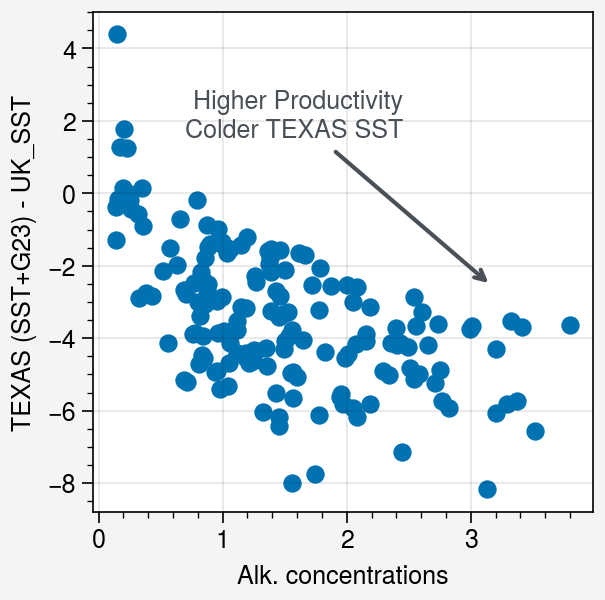

In [33]:
plot_data = (PhanTEX_GIG_df[PhanTEX_GIG_df['SiteName'] == 'U1482']
             [PhanTEX_GIG_df['Age'] < 0.35]
             .copy())                              # ← add this
plot_data['SST_diff'] = (plot_data['pred_SST_TEXAS_scaledRI_cren3'] 
                        - plot_data['pred_SST_TEXAS_scaledRI_cren3_Tg23r'])

plot_alk_conc_data = (
    Tran2025_df[Tran2025_df['Age'] < 0.35] 
    .reset_index(drop=True)
)

plot_alk_conc_data = plot_alk_conc_data.sort_values('Age')
alk_conc_interp = np.interp(
    plot_data['Age'],
    plot_alk_conc_data['Age'],
    plot_alk_conc_data['uk37_total']  
)

uk_sst_interp = np.interp(
    plot_data['Age'],
    plot_alk_conc_data['Age'],
    plot_alk_conc_data['sst_uk_med']  
)

sst_TEXAS_uk_diff = plot_data['pred_SST_TEXAS_scaledRI_cren3_Tg23r'] - uk_sst_interp

fig, axs = plot.subplots(ncols=1,share=0)

# ax = axs[0]
# ax.scatter(plot_data['gdgt23ratio'],plot_data['SST_diff'])

ax = axs[0]
ax.scatter(alk_conc_interp,sst_TEXAS_uk_diff)
ax.set_xlabel('Alk. concentrations')
ax.set_ylabel('TEXAS (SST+G23) - UK_SST')

# ax.annotate('', 
#             xy=(0.98, 0.55), xycoords='axes fraction',      # arrow head
#             xytext=(0.98, 0.95), textcoords='axes fraction', # arrow tail
#             arrowprops=dict(arrowstyle='->', color='gray7', lw=1.5))
# ax.text(0.98, 0.97, 'Higher\nProductivity',
#         transform=ax.transAxes, fontsize=9, color='gray7',
#         ha='right', va='top')
# ax.text(0.98, 0.52, 'Colder\nTEXAS SST',
#         transform=ax.transAxes, fontsize=9, color='gray7',
#         ha='right', va='top')

ax.annotate('Higher Productivity\nColder TEXAS SST', 
            xy=(0.8, 0.45), xycoords='axes fraction',       # arrow head
            xytext=(0.62, 0.75), textcoords='axes fraction',  # text + tail
            fontsize=9, color='gray7', ha='right',
            arrowprops=dict(arrowstyle='->', color='gray7', lw=1.5))

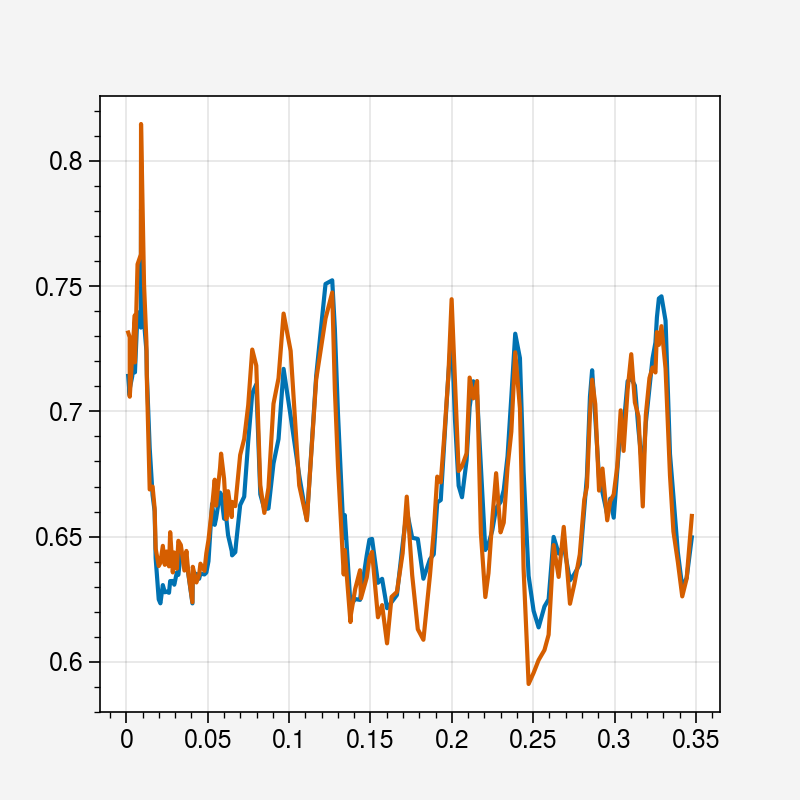

In [34]:
plot_data = PhanTEX_GIG_df[PhanTEX_GIG_df['SiteName']=='U1482'][PhanTEX_GIG_df['Age']<0.35]
plt.plot(plot_data['Age'].values,plot_data['TEX86'].values)
plt.plot(plot_data['Age'].values,plot_data['scaledRI_cren3'].values)

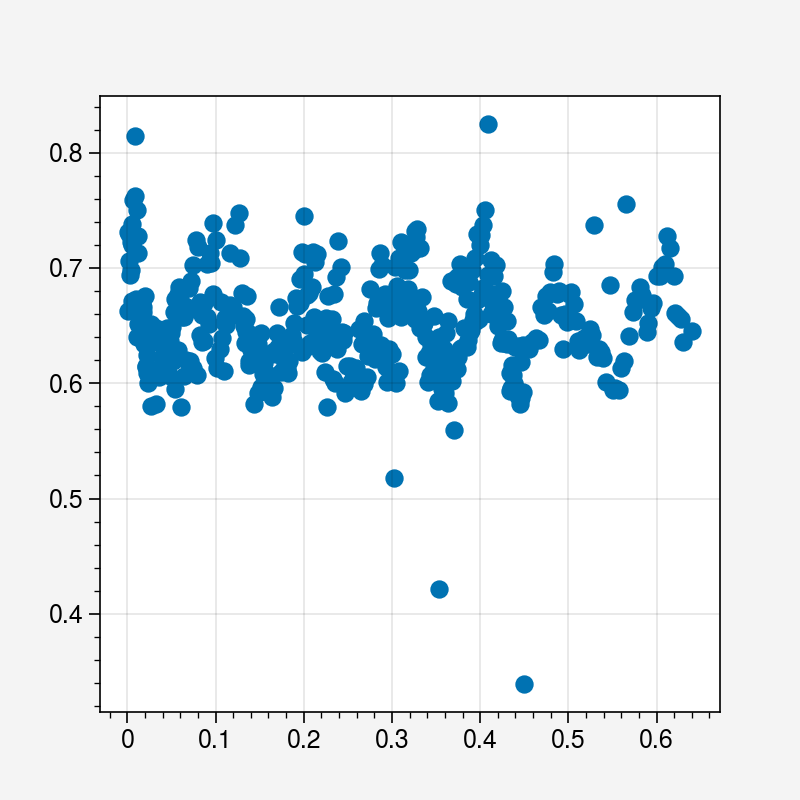

In [35]:
plot_data = PhanTEX_GIG_df
plt.scatter(plot_data['Age'],plot_data['scaledRI_cren3'])

In [36]:
import xarray as xr
import xesmf as xe
import numpy as np
import gc
import os
import hashlib

def regrid_curvilinear_to_latlon(
    ds,
    var_names,
    lat_name=None,
    lon_name=None,
    target_res=0.5,
    lat_range=(-90, 90),
    lon_range=(0, 360),
    method='bilinear',
    periodic=True,
    squeeze_dims=None,
    keep_attrs=True,
):
    """
    Regrid data from curvilinear grid to regular lat/lon grid.
    """
    regridder = None
    
    # Create unique weight filename based on grid configuration
    grid_config = f"{method}_{target_res}_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}"
    grid_hash = hashlib.md5(grid_config.encode()).hexdigest()[:8]
    weight_file = f'regrid_weights_{grid_hash}.nc'
    
    try:
        if isinstance(var_names, str):
            var_names = [var_names]
        
        # Auto-detect lat/lon coordinate names
        if lat_name is None or lon_name is None:
            print("Auto-detecting coordinate names...")
            
            lat_candidates = ['TLAT', 'lat', 'latitude', 'LAT', 'Lat']
            lon_candidates = ['TLONG', 'lon', 'longitude', 'LON', 'Lon', 'LONG']
            
            for lat_cand in lat_candidates:
                if lat_cand in ds:
                    lat_name = lat_cand
                    print(f"  Found latitude: {lat_name}")
                    break
            
            for lon_cand in lon_candidates:
                if lon_cand in ds:
                    lon_name = lon_cand
                    print(f"  Found longitude: {lon_name}")
                    break
            
            if lat_name is None or lon_name is None:
                raise ValueError(
                    f"Could not auto-detect coordinates.\n"
                    f"Available variables: {list(ds.variables)}\n"
                    f"Please specify lat_name and lon_name explicitly."
                )
        
        # Get dimensions
        lat_dims = ds[lat_name].dims
        lon_dims = ds[lon_name].dims
        
        if lat_dims != lon_dims:
            raise ValueError(
                f"Latitude and longitude have different dimensions:\n"
                f"  {lat_name}: {lat_dims}\n"
                f"  {lon_name}: {lon_dims}"
            )
        
        if len(lat_dims) != 2:
            raise ValueError(
                f"Expected 2D coordinates, got {len(lat_dims)}D: {lat_dims}"
            )
        
        lat_dim, lon_dim = lat_dims
        print(f"  Dimensions: {lat_dim}, {lon_dim}")
        
        # Get source coordinates
        lat_vals = ds[lat_name].values.copy()
        lon_vals = ds[lon_name].values.copy()
        
        print(f"\nSource coordinates:")
        print(f"  Lat range: [{lat_vals.min():.2f}, {lat_vals.max():.2f}]")
        print(f"  Lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Convert source longitudes if needed
        if lon_range[0] < 0 and lon_vals.min() >= 0:
            # Target is -180-180 but source is 0-360
            print(f"  Converting source lon from [0, 360] to [-180, 180]...")
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        elif lon_range[0] >= 0 and lon_vals.min() < 0:
            # Target is 0-360 but source is -180-180
            print(f"  Converting source lon from [-180, 180] to [0, 360]...")
            lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Create source grid
        print("\nCreating source grid...")
        ds_in = xr.Dataset({
            'lat': ([lat_dim, lon_dim], lat_vals),
            'lon': ([lat_dim, lon_dim], lon_vals),
        })
        
        # Create target grid
        print("Creating target grid...")
        print(f"  Lat range: {lat_range}")
        print(f"  Lon range: {lon_range}")
        print(f"  Resolution: {target_res}°")
        
        lat_out = np.arange(lat_range[0], lat_range[1] + target_res/2, target_res)
        lon_out = np.arange(lon_range[0], lon_range[1] + target_res/2, target_res)
        
        ds_out = xr.Dataset({
            'lat': (['lat'], lat_out),
            'lon': (['lon'], lon_out),
        })
        
        print(f"  Target grid: {len(lat_out)} x {len(lon_out)}")
        
        # Check if weight file exists
        if os.path.exists(weight_file):
            print(f"\nFound existing weight file: {weight_file}")
            reuse_weights = True
        else:
            print(f"\nWeight file not found, will create: {weight_file}")
            print(f"  (Grid config hash: {grid_hash})")
            reuse_weights = False
        
        # Create regridder
        print(f"Creating regridder (method: {method})...")
        try:
            regridder = xe.Regridder(
                ds_in, ds_out, 
                method, 
                periodic=periodic,
                filename=weight_file,
                reuse_weights=reuse_weights
            )
            print("✓ Regridder created")
        except Exception as e:
            if reuse_weights and os.path.exists(weight_file):
                print(f"⚠ Error reusing weights, deleting and recreating...")
                os.remove(weight_file)
                regridder = xe.Regridder(
                    ds_in, ds_out, 
                    method, 
                    periodic=periodic,
                    filename=weight_file,
                    reuse_weights=False
                )
                print("✓ Regridder created")
            else:
                raise e
        
        # Regrid variables
        regridded_vars = {}
        for var_name in var_names:
            print(f"\n{'='*60}")
            print(f"Regridding {var_name}...")
            print(f"{'='*60}")
            
            if var_name not in ds:
                print(f"  ⚠ Warning: {var_name} not found in dataset, skipping")
                continue
            
            var = ds[var_name]
            
            # Squeeze dimensions
            if squeeze_dims is not None:
                if isinstance(squeeze_dims, str):
                    squeeze_dims = [squeeze_dims]
                for dim in squeeze_dims:
                    if dim in var.dims:
                        var = var.squeeze(dim)
                        print(f"  Squeezed dimension: {dim}")
            
            print(f"  Original shape: {var.shape}")
            print(f"  Original dims: {var.dims}")
            
            # Find time dimension
            time_dim = None
            for dim in var.dims:
                if dim not in [lat_dim, lon_dim]:
                    time_dim = dim
                    break
            
            # Regrid
            if time_dim and time_dim in var.dims:
                print(f"  Processing {var.sizes[time_dim]} time steps...")
                regridded_list = []
                n_time = var.sizes[time_dim]
                
                for t in range(n_time):
                    print(f"    Time step {t+1}/{n_time}", end='\r')
                    chunk = var.isel({time_dim: t})
                    chunk_regrid = regridder(chunk)
                    regridded_list.append(chunk_regrid)
                    del chunk
                
                print(f"    Time step {n_time}/{n_time} - Done!     ")
                
                var_regridded = xr.concat(regridded_list, dim=time_dim)
                var_regridded = var_regridded.assign_coords({time_dim: var[time_dim]})
                
                del regridded_list
                gc.collect()
            else:
                print(f"  Processing single time step...")
                var_regridded = regridder(var)
            
            # Assign coordinates
            var_regridded = var_regridded.assign_coords({
                'lat': ds_out.lat,
                'lon': ds_out.lon,
            })
            
            if keep_attrs:
                var_regridded.attrs = var.attrs
            
            regridded_vars[var_name] = var_regridded
            print(f"  ✓ {var_name} regridded successfully")
            print(f"  Output shape: {var_regridded.shape}")
        
        # Create output dataset
        ds_regridded = xr.Dataset(regridded_vars)
        
        if keep_attrs:
            ds_regridded.attrs = ds.attrs
        
        print(f"\n{'='*60}")
        print("✓ ALL VARIABLES REGRIDDED SUCCESSFULLY!")
        print(f"  Weight file: {weight_file}")
        print(f"  Variables: {list(regridded_vars.keys())}")
        print(f"  Output lon range: [{ds_regridded.lon.min().values:.2f}, {ds_regridded.lon.max().values:.2f}]")
        print(f"{'='*60}")
        
        return ds_regridded
        
    finally:
        # Cleanup
        if regridder is not None:
            print("\nCleaning up...")
            del regridder
        
        gc.collect()
        print("✓ Cleanup complete")

In [37]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

<xarray.DataArray 't_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6392   , -1.64001  , -1.64101  , ..., -1.63711  ,
         -1.6377   , -1.63831  ],
        [-1.6605101, -1.66081  , -1.66111  , ..., -1.6593   ,
         -1.65961  , -1.6601   ],
        [-1.67591  , -1.67591  , -1.67591  , ..., -1.67591  ,
         -1.67591  , -1.67591  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

# PETM climate simulations and PETM-DA

In [38]:
# import glob
# import re

# fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim'
# fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

# pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
# ### find files with iPETM and pop.h in the name
# ipetm_re = re.compile(r'iPETM\d+x')


# matches = glob.glob(pattern)

# for fn in glob.glob(pattern):
#     basename = os.path.basename(fn)
#     m = ipetm_re.search(basename)
#     if m:
#         print(m.group(0))   # → iPETM09x
#         print(basename)
#     else:
#         print(f"No iPETM token found in {basename}")
    
    
#     ds = xr.open_dataset(fn)
#     display(ds)
    
#     break 

#     ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

#     ds_TEMP = ds['TEMP']
#     ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
#     ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

#     # 1. Define your target grid
#     lat_out = np.arange(T_1deg_da.lat.min(), T_1deg_da.lat.max()+0.1, 1.0)
#     lon_out = np.arange(T_1deg_da.lon.min(), T_1deg_da.lon.max()+0.1, 1.0)
    
#     ds_out = xr.Dataset({
#         "lat": (["lat"], lat_out),
#         "lon": (["lon"], lon_out),
#     })

#     # 2. Create the regridder and interpolate
#     regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
#     field_reg = regridder(ds_TEMP)
#     field_reg.name = 'TEMP'

#     fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
#     fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
#     field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
#     print(f"Saved regridded data to {os.path.join(fpath, fname)}")



fpath = fr'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM01x.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM03x.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM06x.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM09x.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))



In [39]:
# fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
# fname = 'PETMDA_OCN_annual.nc'
# PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

# PETMDA_ds_regridded = regrid_curvilinear_to_latlon(
#     PETMDA_ds,
#     var_names=['sst'],
#     target_res=1.0,
#     lat_range=(T_1deg_da.lat.min(), T_1deg_da.lat.max()+1.0),
#     lon_range=(T_1deg_da.lon.min(), T_1deg_da.lon.max()+1.0),
# )
    
# fname = 'PETMDA_OCN_annual_regridded.nc'
# PETMDA_ds_regridded.to_netcdf(os.path.join(fpath,fname), mode='w', format='NETCDF4', unlimited_dims='time')

fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual_regridded.nc'
PETMDA_ds_regridded = xr.open_dataset(os.path.join(fpath,fname))
PETMDA_ds_regridded

<xarray.Dataset>
Dimensions:  (lat: 181, lon: 361, nTime: 2)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 87.5 88.5 89.5 90.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 178.5 179.5 180.5
  * nTime    (nTime) int64 0 1
Data variables:
    sst      (nTime, lat, lon) float64 ...
Attributes:
    creation_date:  20-Mar-2022 13:04:58
    author:         Dr. Jessica E. Tierney, University of Arizona
    description:    Posterior annual ocean variables for the PETM DA

In [40]:
PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')


In [41]:
PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'].sum()

1473

In [42]:
site_names_list = ['Wilson Lake','ODP1172','ODP959','South Dover Bridge']
PhanTEX_PETM_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False][PhanTEX_df['SiteName'].isin(site_names_list)].reset_index(drop=True)

### for Bass River --- keep only samples with SampleDepth 350 - 400 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='Bass River') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 380) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 390)
                                    )
                                   )].reset_index(drop=True)

### for ODP1172 --- keep only samples with Age 50 - 55 Ma
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP1172') & 
                                    ( (PhanTEX_PETM_df['Age'] < 55.85) | 
                                      (PhanTEX_PETM_df['Age'] > 56.1)
                                    )
                                   )].reset_index(drop=True)

### for IB10B --- keep only samples with SampleDepth 50 - 90 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='IB10B') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 60) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 95)
                                    )
                                   )].reset_index(drop=True)

### for ODP959 --- keep only samples with MBSF 790 to 810 m and pubYear Frieling2018
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP959') & 
                                    ( (PhanTEX_PETM_df['MBSF'] < 801) | 
                                      (PhanTEX_PETM_df['MBSF'] > 810) |
                                      (PhanTEX_PETM_df['pubYear'] != 'Frieling2018')
                                    )
                                   )].reset_index(drop=True)

### for South Dover Bridge --- keep only samples with Sample Depth from 611
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='South Dover Bridge') & 
                                    ((PhanTEX_PETM_df['SampleDepth'] < 611) | 
                                     (PhanTEX_PETM_df['SampleDepth'] > 700)
                                    )
                                   )].reset_index(drop=True)

In [43]:
PhanTEX_PETM_df['SiteName'] = PhanTEX_PETM_df['SiteName'].replace({
    'South Dover Bridge': 'SDB',
    'Wilson Lake': 'WL'
})

PhanTEX_PETM_df['SiteName'].unique()

array(['ODP1172', 'ODP959', 'SDB', 'WL'], dtype=object)

In [44]:
PETM_interval_dict_sampleDepth = {
    'ODP174AX Ancora': (165.5,171.5),
    'WL': (96.5, 109.5),
    'Bass River': (382.5,386),
    'IB10B': (70,80),
    'SDB': (635, 665),
}

PETM_interval_dict_Age = {
    'ODP1172': (55.94, 56.01),
}

PETM_interval_MBSF_dict = {
    'ODP959': (803.05,804.05),
}

### assign 'PETM', 'pre-PETM', 'post-PETM' based on Age or SampleDepth
PhanTEX_PETM_df['PETM_interval'] = 'non-PETM'
for i in range(len(PhanTEX_PETM_df)):
    site_name = PhanTEX_PETM_df.loc[i,'SiteName']
    if site_name in PETM_interval_dict_sampleDepth.keys():
        sample_depth = PhanTEX_PETM_df.loc[i,'SampleDepth']
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        print(f"Site: {site_name}, SampleDepth: {sample_depth}, PETM interval: {petm_start}-{petm_end}")
        if sample_depth >= petm_start and sample_depth <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif sample_depth < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif sample_depth > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_dict_Age.keys():
        age = PhanTEX_PETM_df.loc[i,'Age']
        petm_start, petm_end = PETM_interval_dict_Age[site_name]
        print(f"Site: {site_name}, Age: {age}, PETM interval: {petm_start}-{petm_end}")
        if age >= petm_start and age <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif age < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif age > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_MBSF_dict.keys():
        mbsf = PhanTEX_PETM_df.loc[i,'MBSF']
        petm_start, petm_end = PETM_interval_MBSF_dict[site_name]
        if mbsf >= petm_start and mbsf <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif mbsf < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
        elif mbsf > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'


Site: ODP1172, Age: 55.864, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8657, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8836, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8972, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8997, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9176, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9244, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9337, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9439, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9516, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9592, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9728, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.983, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9898, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9958, PETM interval: 55.94-

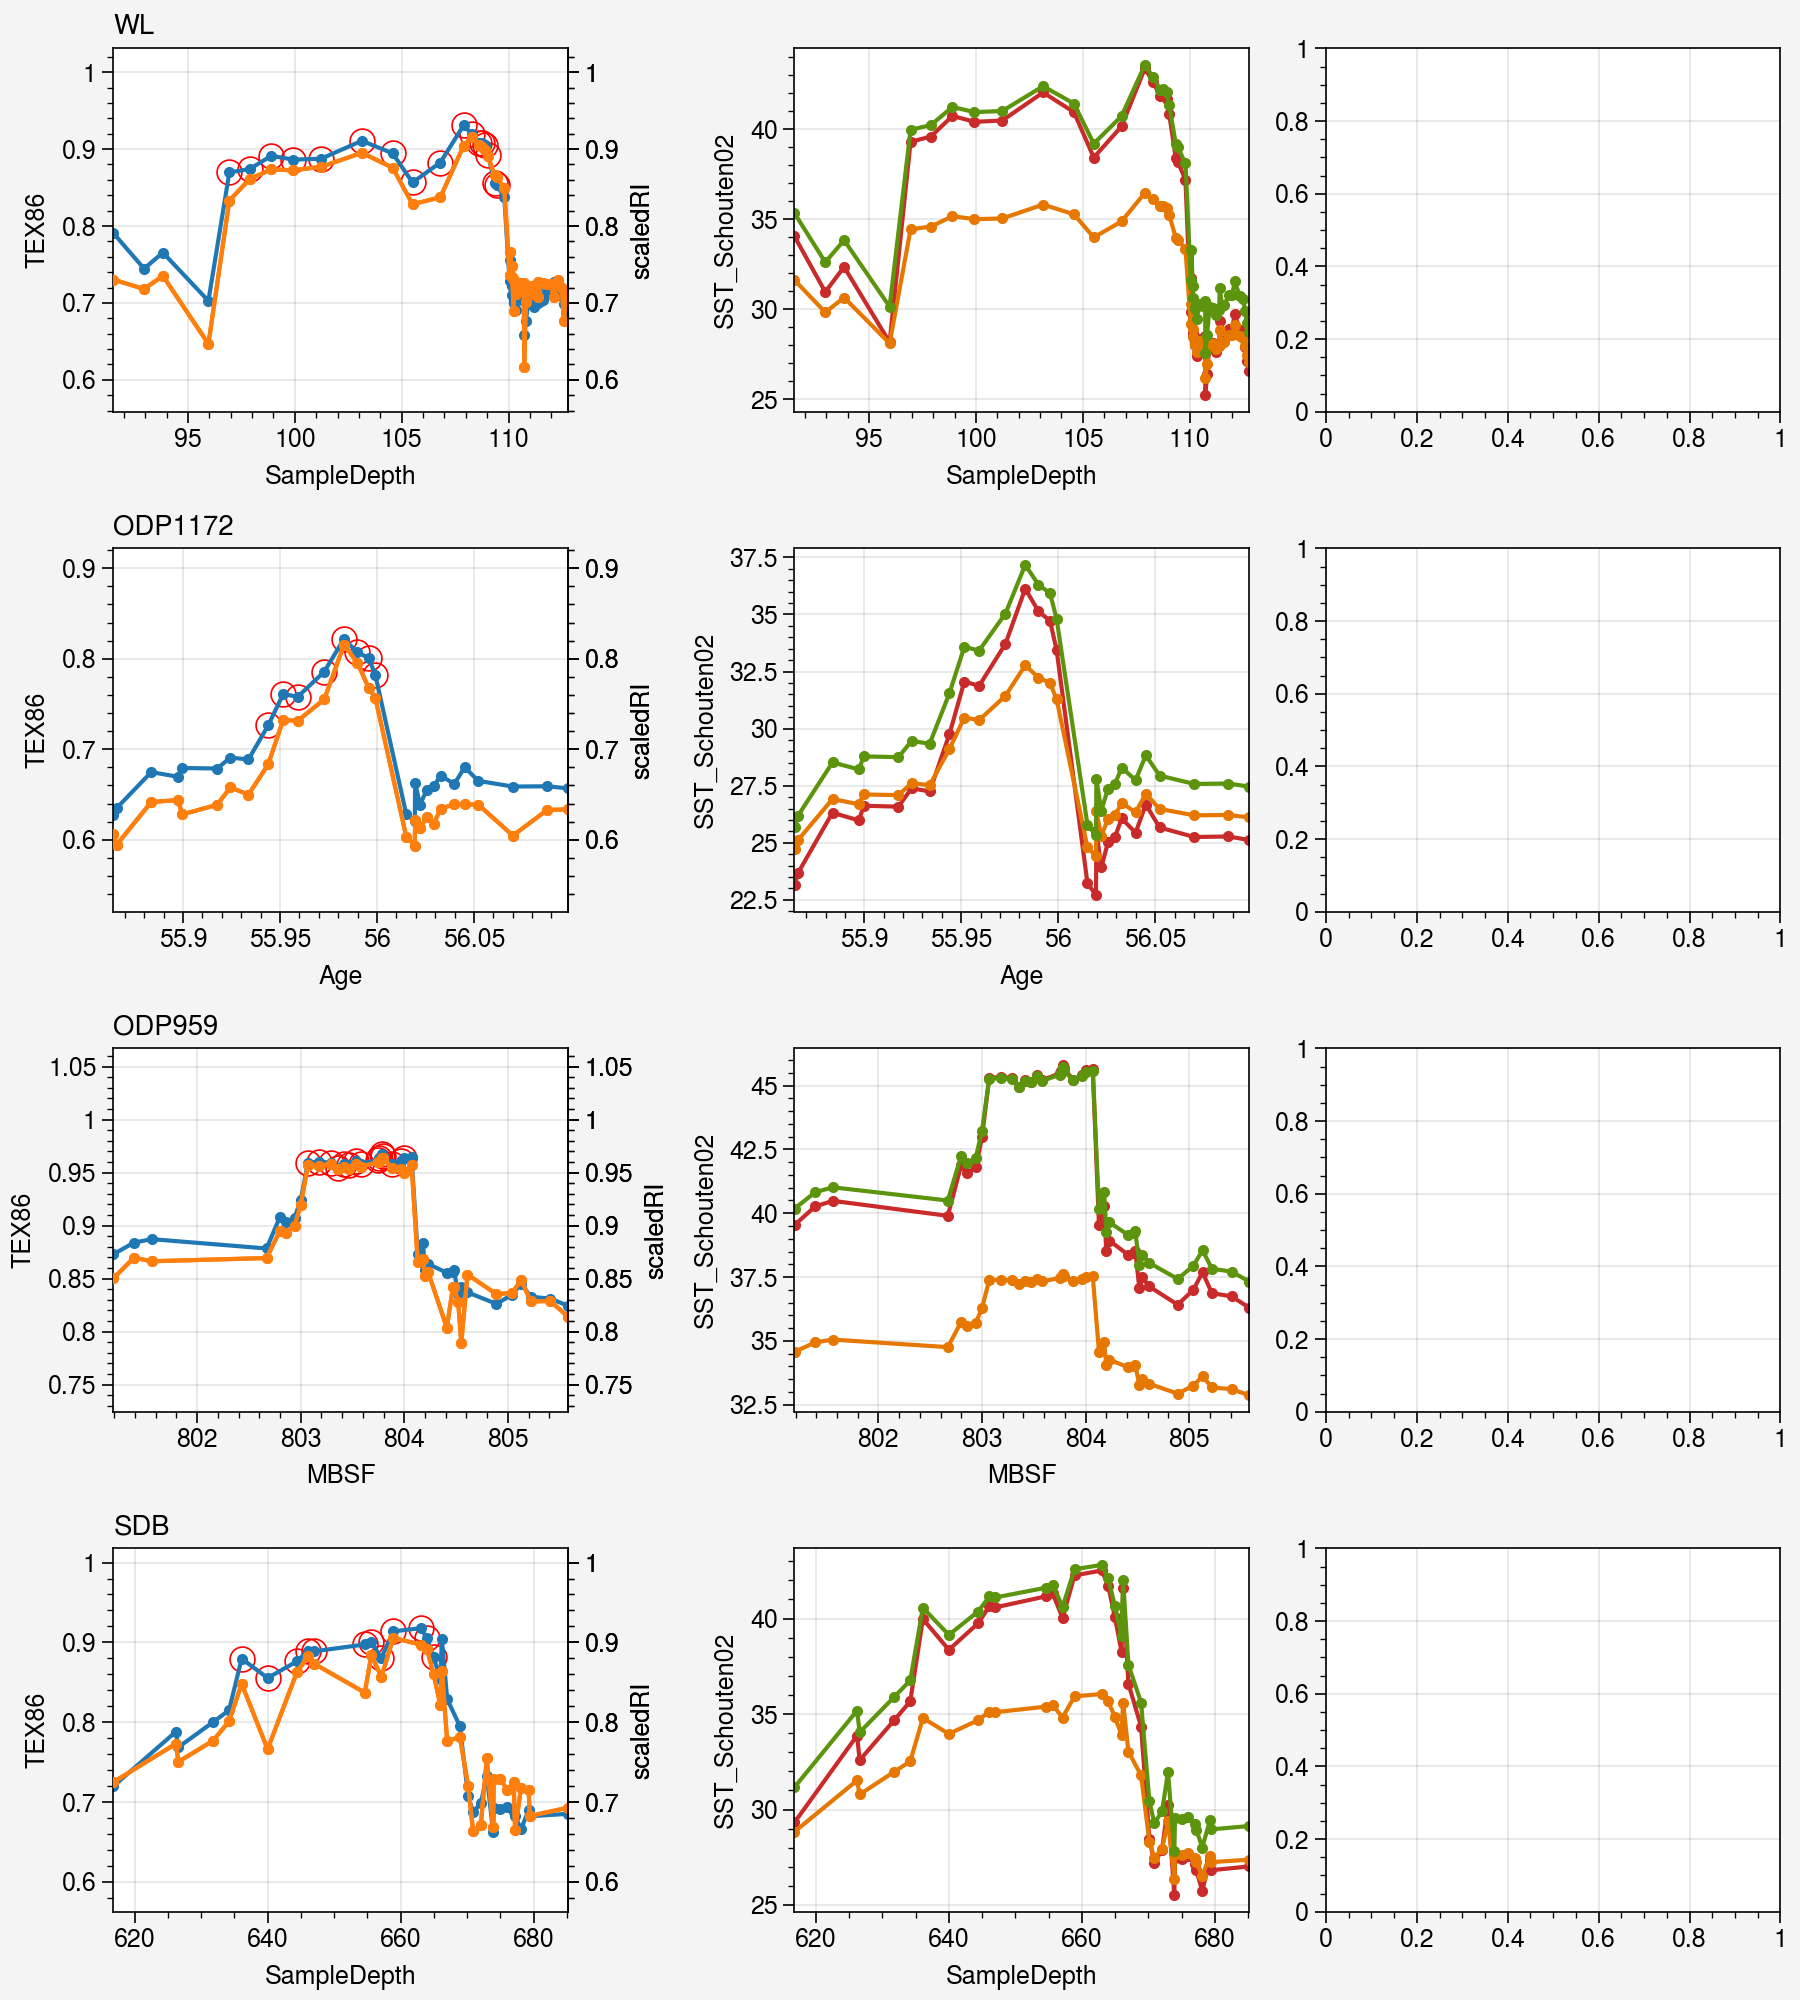

In [45]:
site_names_list = ['WL','ODP1172','ODP959','SDB']
fig, axs = plot.subplots(width=9,nrows=len(site_names_list),ncols=3, height=10, share=0)

for i, site_name in enumerate(site_names_list):
    sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]
    
    if site_name == 'ODP959':
        plot_data = sel_site_df.sort_values('MBSF').reset_index(drop=True)
        # Plot on primary axis
        axs[i,0].plot(plot_data['MBSF'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['MBSF'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['MBSF'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    
    elif sel_site_df['SampleDepth'].isnull().all():
        plot_data = sel_site_df.sort_values('Age').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['Age'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['Age'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['Age'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        

    else:
        plot_data = sel_site_df.sort_values('SampleDepth').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['SampleDepth'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['SampleDepth'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['SampleDepth'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    axs[i,0].format(ltitle=site_name)

In [46]:
grouped_site_df = PhanTEX_PETM_df.groupby('SiteName')
for site_name, sel_site_df in grouped_site_df:
    print(f"Site: {site_name}")
    
    search_tolerance = np.std(sel_site_df['TEX86'], ddof=1) * 2 if site_name != 'ODP959' else 0.25
    print(np.std(sel_site_df['TEX86'], ddof=1) * 2)
    print("Search tolerance based on 2*SD of TEX86 values: ", f"{search_tolerance:.4f}")
    print(f"  Search tolerance: {search_tolerance:.4f}")

    pred_bsr_sst = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30,
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='sst',
            search_tol=search_tolerance,
            nens=100).percentile([10, 16, 25, 40, 50, 60, 75, 84, 90])
    # Index:                       0   1   2   3   4   5   6   7   8

    pred_bsr_subt = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30,
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='subt',
            search_tol=search_tolerance,
            nens=100).percentile([10, 16, 25, 40, 50, 60, 75, 84, 90])
    # Index:                       0   1   2   3   4   5   6   7   8

    ### add median predictions (P50) to dataframe
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_pred']  = pred_bsr_sst[:, 4]   # P50
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_pred'] = pred_bsr_subt[:, 4]  # P50

    ### collect SST percentiles
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P10'] = pred_bsr_sst[:, 0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P16'] = pred_bsr_sst[:, 1]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P25'] = pred_bsr_sst[:, 2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P40'] = pred_bsr_sst[:, 3]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P60'] = pred_bsr_sst[:, 5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P75'] = pred_bsr_sst[:, 6]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P84'] = pred_bsr_sst[:, 7]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P90'] = pred_bsr_sst[:, 8]

    ### collect subt percentiles
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P10'] = pred_bsr_subt[:, 0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P16'] = pred_bsr_subt[:, 1]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P25'] = pred_bsr_subt[:, 2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P40'] = pred_bsr_subt[:, 3]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P60'] = pred_bsr_subt[:, 5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P75'] = pred_bsr_subt[:, 6]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P84'] = pred_bsr_subt[:, 7]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P90'] = pred_bsr_subt[:, 8]

PhanTEX_PETM_df

Site: ODP1172
0.11864593454222733
Search tolerance based on 2*SD of TEX86 values:  0.1186
  Search tolerance: 0.1186


  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 83.75it/s]


Site: ODP959
0.10639670472162806
Search tolerance based on 2*SD of TEX86 values:  0.2500
  Search tolerance: 0.2500


100%|██████████| 17/17 [00:00<00:00, 75.32it/s]


Site: SDB
0.1857412827326765
Search tolerance based on 2*SD of TEX86 values:  0.1857
  Search tolerance: 0.1857


100%|██████████| 24/24 [00:00<00:00, 81.49it/s]


Site: WL
0.17842919653943046
Search tolerance based on 2*SD of TEX86 values:  0.1784
  Search tolerance: 0.1784


100%|██████████| 25/25 [00:00<00:00, 72.23it/s]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,BSR_SST_P84,BSR_SST_P90,BSR_subt_P10,BSR_subt_P16,BSR_subt_P25,BSR_subt_P40,BSR_subt_P60,BSR_subt_P75,BSR_subt_P84,BSR_subt_P90
0,PhanTEX_RR4681,ODP1172,D,611.000,NaN,NaN,NaN,NaN,so,-43.96,...,27.608433,28.777227,16.134643,17.093791,18.225951,19.807059,21.758976,23.345526,24.719323,25.794699
1,PhanTEX_RR4682,ODP1172,D,611.010,NaN,NaN,NaN,NaN,so,-43.96,...,28.111741,29.506004,16.545257,17.548938,18.688231,20.247773,22.174690,23.770904,25.191588,26.315451
2,PhanTEX_RR4683,ODP1172,D,611.115,NaN,NaN,NaN,NaN,so,-43.96,...,31.014697,32.552960,19.211292,20.213621,21.307319,22.902513,24.920553,26.944653,28.384125,29.545730
3,PhanTEX_RR4684,ODP1172,D,611.195,NaN,NaN,NaN,NaN,so,-43.96,...,30.733691,32.026754,18.705452,19.830726,20.984524,22.545493,24.706720,26.431197,27.793500,28.993821
4,PhanTEX_RR4685,ODP1172,D,611.210,NaN,NaN,NaN,NaN,so,-43.96,...,31.519977,32.974051,19.170953,20.362268,21.645924,23.406887,25.279784,27.099230,28.454890,29.798261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,PhanTEX_RR7885,SDB,NaN,NaN,NaN,677.20,NaN,United States of America,na,38.70,...,31.193586,32.725965,18.817349,20.010798,21.220353,23.001652,25.075121,26.919704,28.457523,29.624311
150,PhanTEX_RR7886,SDB,NaN,NaN,NaN,678.10,NaN,United States of America,na,38.70,...,30.147935,31.475544,17.729601,18.918777,20.267155,22.136948,24.049806,25.847186,27.214400,28.562704
151,PhanTEX_RR7887,SDB,NaN,NaN,NaN,679.25,NaN,United States of America,na,38.70,...,31.625131,32.997933,19.199445,20.422662,21.825706,23.588476,25.741750,27.537469,28.997760,30.429200
152,PhanTEX_RR7888,SDB,NaN,NaN,NaN,679.40,NaN,United States of America,na,38.70,...,31.158713,32.619597,18.776502,20.072665,21.326277,23.082610,25.180685,27.075632,28.571174,30.042571


In [47]:
# from TEXAS.data.builder import InvTConfig, build_invT_inputData

# siteName_grouped = PhanTEX_PETM_df.groupby('SiteName')
# temp_params = ['SST','thermoT'] # or thermoT 'SST',
# temp_types = ['sst','thermoT'] # or thermoT 'sst',
# date_tag = '032326'
# y_param = 'scaledRI_cren3'

# no3_thershold_dict = {
#     'thermoT':'1.9'
# }

# for i, (temp_param,temp_type) in enumerate(zip(temp_params,temp_types)):
#     for name, group in siteName_grouped:
#         print(name)
#         #######################
#         fwd_post = f"gen_logi_fixed_hier_crtp_univ_priorApprox_{temp_param}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )
        
#         ########################
#         fwd_post = f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             predictors={
#                 'gdgt23ratio':group['gdgt23ratio'].values,
#             },
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )
        
#         ########################
#         modLat = group['ModLat'].iloc[0]
#         modLon = group['ModLon'].iloc[0]
#         modern_no3 = np.atleast_1d(ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat,lon=modLon,method='nearest').values)[0]
        
#         ########################
#         fwd_post = f"gen_logi_fixed_hier_crtp_multiv_priorApprox_{temp_param}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}"
#         predict_T_from_proxyObs(
#             proxyObs=group[y_param].astype(float).tolist(),
#             prior_mu_t = 20.0,
#             prior_sigma_t = 10,
#             fwd_posterior_name=fwd_post,
#             predictors={
#                 'gdgt23ratio':group['gdgt23ratio'].values,
#                 'no3':np.full(len(group), modern_no3),
#             },
#             site_name=name,
#             save_results=True,
#             temptype=f'{temp_type}',
#             filename_tag=f'{date_tag}'
#         )

In [48]:
siteName_list = PhanTEX_PETM_df['SiteName'].unique()

y_param = 'scaledRI_cren3'
temp_params = ['SST','thermoT']
temp_types = ['sst','thermoT']
date_tag = '032326'
no3_thershold_dict = {
    'thermoT':'1.9'
}
for temp_param, temp_type in zip(temp_params,temp_types):
    for site_name in siteName_list:
        
        idx = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name].index
        
        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_univ_unconstrained_{temp_type}_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}'] = predT_.sel(quantile=0.5).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_p84'] = predT_.sel(quantile=0.84).values
        
        ##############################

        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_multiv_unconstrained_{temp_type}_gdgt23ratio_no3_0.0_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r'] = predT_.sel(quantile=0.5).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_p84'] = predT_.sel(quantile=0.84).values
        
        ##############################

        fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
        fname = f"{site_name}_invT_gen_logi_fixed_multiv_unconstrained_{temp_type}_gdgt23ratio_no3_{no3_thershold_dict.get(temp_param,'1.8')}_{y_param}_{date_tag}_direct.nc"
        predT_ = xr.open_dataset(os.path.join(fpath, fname),engine="netcdf4")['t_est']

        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3'] = predT_.sel(quantile=0.5).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p25'] = predT_.sel(quantile=0.25).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p75'] = predT_.sel(quantile=0.75).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p16'] = predT_.sel(quantile=0.16).values
        PhanTEX_PETM_df.loc[idx,f'pred_{temp_param}_TEXAS_{y_param}_Tg23r_no3_p84'] = predT_.sel(quantile=0.84).values
    

In [49]:
PhanTEX_PETM_df['SiteName'].unique()

array(['ODP1172', 'ODP959', 'SDB', 'WL'], dtype=object)

In [50]:
predT_model_list = ['SST_Schouten02', 'SST_Kim10', 'BSR_SST_pred', 'pred_SST_TEXAS_scaledRI_cren3_Tg23r']
site_names = PhanTEX_PETM_df['SiteName'].unique()
diff_data = {}
diff_T_column_list = []


for i, site_name in enumerate(site_names):
    petm_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='PETM')
    
    prePETM_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='pre-PETM')
        
    for predT_model in predT_model_list:
        prePETM_median = PhanTEX_PETM_df.loc[prePETM_idx, predT_model].median()
        
        PhanTEX_PETM_df.loc[petm_idx, f'diffT_{predT_model}'] = PhanTEX_PETM_df.loc[petm_idx, predT_model] - prePETM_median
        
        if i == 0:
            diff_T_column_list.append(f'diffT_{predT_model}')
        
    

diff_data = pd.DataFrame(diff_data, index=[0])
feature = ['SiteName'] + diff_T_column_list
paleo_diffT_df = PhanTEX_PETM_df[PhanTEX_PETM_df['PETM_interval']=='PETM'][feature].copy().reset_index(drop=True)
paleo_diffT_df

,SiteName,diffT_SST_Schouten02,diffT_SST_Kim10,diffT_BSR_SST_pred,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r
0,ODP1172,4.488499,2.889828,4.386390,3.60305
1,ODP1172,6.796716,4.273211,6.620931,6.50055
2,ODP1172,6.605575,4.161070,6.306734,6.48020
3,ODP1172,8.446759,5.224076,8.282911,7.82645
4,ODP1172,10.859963,6.562111,10.412590,10.95895
5,ODP1172,9.880657,6.026366,9.602398,9.89725
6,ODP1172,9.451056,5.788262,9.031026,8.40455
7,ODP1172,8.174544,5.069289,7.957442,7.76625
8,ODP959,7.611003,3.763016,6.885926,5.40505
9,ODP959,7.654391,3.783158,6.675918,5.51420


In [51]:
diffT_PETMDA_da = (PETMDA_ds_regridded['sst'].isel(nTime=0) - PETMDA_ds_regridded['sst'].isel(nTime=1))
diffT_PETMDA_da

<xarray.DataArray 'sst' (lat: 181, lon: 361)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [6.55429488, 6.55420904, 6.55412688, ..., 6.5545155 , 6.55439822,
        6.55429488],
       [6.55925685, 6.55920673, 6.55915695, ..., 6.55935795, 6.55930726,
        6.55925685],
       [6.55525903, 6.55529453, 6.55532939, ..., 6.55518613, 6.55522289,
        6.55525903]])
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 87.5 88.5 89.5 90.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 178.5 179.5 180.5

In [52]:
nonnan_idx = ~PhanTEX_PETM_df['paleolat'].isnull() & ~PhanTEX_PETM_df['paleolon'].isnull()
plot_data = PhanTEX_PETM_df[nonnan_idx].reset_index(drop=True)

In [53]:
plot_data

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_p84,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p25,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p75,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p16,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p84,diffT_SST_Schouten02,diffT_SST_Kim10,diffT_BSR_SST_pred,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r
0,PhanTEX_RR4681,ODP1172,D,611.000,NaN,NaN,NaN,NaN,so,-43.96,...,23.664116,20.42080,17.768000,22.826325,16.372636,23.782960,NaN,NaN,NaN,NaN
1,PhanTEX_RR4682,ODP1172,D,611.010,NaN,NaN,NaN,NaN,so,-43.96,...,23.118928,19.68115,17.030925,21.884250,15.590620,22.924828,NaN,NaN,NaN,NaN
2,PhanTEX_RR4683,ODP1172,D,611.115,NaN,NaN,NaN,NaN,so,-43.96,...,25.653416,22.83950,20.594750,24.775750,19.422992,25.596696,NaN,NaN,NaN,NaN
3,PhanTEX_RR4684,ODP1172,D,611.195,NaN,NaN,NaN,NaN,so,-43.96,...,25.848528,22.92095,20.638450,24.874625,19.530880,25.772032,NaN,NaN,NaN,NaN
4,PhanTEX_RR4685,ODP1172,D,611.210,NaN,NaN,NaN,NaN,so,-43.96,...,25.150668,22.04855,19.771100,24.162050,18.571064,25.027160,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,PhanTEX_RR7885,SDB,NaN,NaN,NaN,677.20,NaN,United States of America,na,38.70,...,26.946892,24.33885,22.205575,26.304725,21.104764,27.195772,NaN,NaN,NaN,NaN
150,PhanTEX_RR7886,SDB,NaN,NaN,NaN,678.10,NaN,United States of America,na,38.70,...,29.575404,26.99150,25.067350,28.722500,24.036860,29.607048,NaN,NaN,NaN,NaN
151,PhanTEX_RR7887,SDB,NaN,NaN,NaN,679.25,NaN,United States of America,na,38.70,...,29.546388,26.83000,25.012275,28.693050,24.096248,29.536576,NaN,NaN,NaN,NaN
152,PhanTEX_RR7888,SDB,NaN,NaN,NaN,679.40,NaN,United States of America,na,38.70,...,28.122020,25.45015,23.491200,27.250550,22.461152,28.104360,NaN,NaN,NaN,NaN


In [54]:
import pygplates

fpath = f'{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model'
rot_filename = 'Muller2019-Young2019-Cao2020_CombinedRotations.rot'
gpml_filename = 'Muller2019-Young2019-Cao2020_COBs.gpmlz'
# ── load files (do this once, outside any loop)
rotation_model    = pygplates.RotationModel(os.path.join(fpath,rot_filename))
coastline_features = pygplates.FeatureCollection(os.path.join(fpath,gpml_filename))

reconstructed_coastlines = []
pygplates.reconstruct(
    coastline_features, rotation_model,
    reconstructed_coastlines,
    56.0,                          # PETM age in Ma
    export_wrap_to_dateline=True,
)

def get_coastline_segments(reconstructed_coastlines):
    segments = []
    for rc in reconstructed_coastlines:
        geom = rc.get_reconstructed_geometry()
        try:
            pts  = geom.to_lat_lon_array()   # shape (N, 2): col0=lat, col1=lon
            lons = pts[:, 1]
            lats = pts[:, 0]
            segments.append((lons, lats))
        except Exception:
            pass                             # skip malformed geometries
    return segments

paleo_coastline_segments = get_coastline_segments(reconstructed_coastlines)
print(f"Loaded {len(paleo_coastline_segments)} coastline segments")  # sanity check

Loaded 914 coastline segments


In [445]:
fpath = f'{local_github_path}/data/spreadsheets/published_data/'
fname = 'SDB_Mgtemp_Gordon_Apr2022.xlsx'

SDB_MgCa_df = pd.read_excel(os.path.join(fpath,fname))
SDB_MgCa_df

,Species,Depth_ft,Depth_m,MgCa_mmol_mol,Temp_low,Temp,Temp_high
0,Acarinina,689.05,210.02244,3.329530,25.275651,26.848233,29.618891
1,Acarinina,686.05,209.10804,3.337283,25.310276,26.885826,29.661797
2,Acarinina,679.55,207.12684,3.514964,23.975082,25.436199,28.007277
3,Acarinina,675.30,205.83144,3.927196,25.625865,27.228463,30.052863
4,Acarinina,673.05,205.14564,3.102146,24.222675,25.705012,28.314084
5,Acarinina,672.05,204.84084,3.603624,26.453254,28.126764,31.078131
6,Acarinina,663.55,202.25004,4.217424,26.607191,28.293894,31.268884
7,Acarinina,662.30,201.86904,4.549972,27.736974,29.520506,32.668867
8,Acarinina,640.80,195.31584,4.264365,26.989158,28.708598,31.742203
9,Acarinina,639.05,194.78244,4.245711,26.923899,28.637746,31.661336


In [448]:
PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName'].isin(['SDB','ODP959'])]

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_p84,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p25,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p75,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p16,pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_p84,diffT_SST_Schouten02,diffT_SST_Kim10,diffT_BSR_SST_pred,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r
29,PhanTEX_RR6582,ODP959,D,801.19,NaN,NaN,NaN,NaN,at,3.63,...,37.551960,34.40680,32.407225,36.601950,31.505976,37.911948,NaN,NaN,NaN,NaN
30,PhanTEX_RR6583,ODP959,D,801.39,NaN,NaN,NaN,NaN,at,3.63,...,39.079636,35.37755,33.329700,37.661650,32.525324,39.099368,NaN,NaN,NaN,NaN
31,PhanTEX_RR6584,ODP959,D,801.56,NaN,NaN,NaN,NaN,at,3.63,...,38.543924,35.29535,33.182375,37.777600,32.328428,39.250152,NaN,NaN,NaN,NaN
32,PhanTEX_RR6585,ODP959,D,802.67,NaN,NaN,NaN,NaN,at,3.63,...,38.545848,35.27160,33.176625,37.772525,32.337868,39.217756,NaN,NaN,NaN,NaN
33,PhanTEX_RR6586,ODP959,D,802.80,NaN,NaN,NaN,NaN,at,3.63,...,40.653980,36.77605,34.523325,39.620525,33.524944,41.159848,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,PhanTEX_RR7885,SDB,NaN,NaN,NaN,677.20,NaN,United States of America,na,38.70,...,26.946892,24.33885,22.205575,26.304725,21.104764,27.195772,NaN,NaN,NaN,NaN
150,PhanTEX_RR7886,SDB,NaN,NaN,NaN,678.10,NaN,United States of America,na,38.70,...,29.575404,26.99150,25.067350,28.722500,24.036860,29.607048,NaN,NaN,NaN,NaN
151,PhanTEX_RR7887,SDB,NaN,NaN,NaN,679.25,NaN,United States of America,na,38.70,...,29.546388,26.83000,25.012275,28.693050,24.096248,29.536576,NaN,NaN,NaN,NaN
152,PhanTEX_RR7888,SDB,NaN,NaN,NaN,679.40,NaN,United States of America,na,38.70,...,28.122020,25.45015,23.491200,27.250550,22.461152,28.104360,NaN,NaN,NaN,NaN


Reference: SDB ['Inglis2023', 'Inglis2015']
Reference: ODP959 ['Frieling2018']


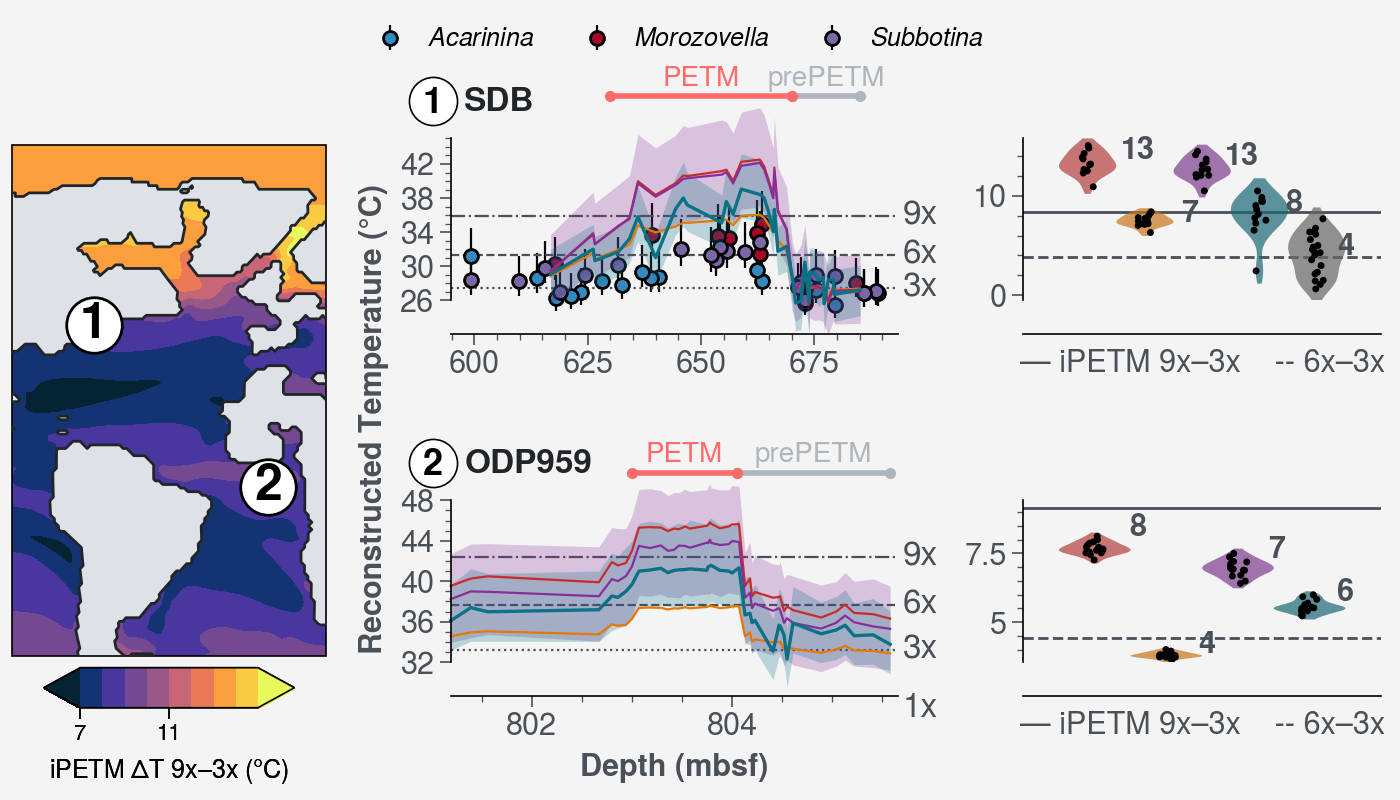

In [468]:
import matplotlib.colors as mcolors

# ============================================================
# CONTROL PANEL — edit only this block
# ============================================================
selected_sites = ['SDB','ODP959']   # ← add/remove/reorder freely

PETM_interval_dict_sampleDepth = {
    'ODP959': (803, 804.05),
    'WL':     (96.5, 109.5),
    'SDB':    (630, 670),       # ← set SDB PETM interval in ft
}
prePETM_depth_dict = {          # ← pre-PETM baseline depth range per site (ft or mbsf)
    'SDB': (670, 690),
}
ylim_dict = {
    'WL':     (24, 45),
    'ODP959': (32, 48),
    'SDB':    (26, 45),
}
published_T_sites = ['WL']

def get_published_T(site_name, group):
    if site_name == 'WL':
        return (group['TEX86'] - 0.016) / 0.027
    return None

# (site_row_idx, iPETM_idx) pairs where the CO2 label is skipped
iPETM_label_skip = {(0, 0)}

# per-site Mg/Ca dataframes — None means skip
MgCa_df_dict = {
    'SDB': SDB_MgCa_df,   # must have columns: depth_col, 'T_est', 'lower_T_est', 'higher_T_est'
}
MgCa_depth_col = 'Depth_ft'   # depth column name in Mg/Ca df

# map padding
pad_latmax, pad_latmin = 50, 50
pad_lonmin, pad_lonmax = 20, 20

# figure sizing
height_per_site = 2
map_span_rows = 2

# ── in CONTROL PANEL
map_label_offset = {
    # (lon_offset, lat_offset) in degrees — tweak per site
    'WL':     (-4,  2),
    'SDB':    (0,  0),
    'ODP959': ( 3, -3),
}
# ============================================================
# LOOKUP DICTS
# ============================================================
temp_methods = [
    'SST_Schouten02',
    'SST_Kim10',
    'BSR_SST_pred',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r',
]
temp_T_range_dict = {
    'BSR_SST_pred': ('BSR_SST_P16', 'BSR_SST_P84'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r': (
        'pred_SST_TEXAS_scaledRI_cren3_Tg23r_p16',
        'pred_SST_TEXAS_scaledRI_cren3_Tg23r_p84'),
}
plot_colors = ['red9', 'yellow9', 'grape9', 'cyan9']
plot_styles  = ['-', '-', '-', '-']
ts_labels    = ['Schouten et al. (2002)', 'Kim et al. (2010)',
                'BSR SST Prediction', 'TEXAS (T + G23)']

# violin color config: base 4 methods + optional Mg/Ca (gray)
base_vio_colors  = ['red9', 'yellow9', 'grape9', 'cyan9']
mgca_vio_color   = '#666666'

# ============================================================
# DATA PREP
# ============================================================
n_sites = len(selected_sites)

plot_data = (
    PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName'].isin(selected_sites)]
    [PhanTEX_PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False]
    .sort_values('SampleDepth')
    .reset_index(drop=True)
)
plot_data['SiteName'] = pd.Categorical(
    plot_data['SiteName'], categories=selected_sites, ordered=True
)

# map extent from paleo coords
site_lats = plot_data.groupby('SiteName')['paleolat'].first()
site_lons = plot_data.groupby('SiteName')['paleolon'].first()
lat_min = max(site_lats.min() - pad_latmin, -90)
lat_max = min(site_lats.max() + pad_latmax,  90)
lon_min = max(site_lons.min() - pad_lonmin, -180)
lon_max = min(site_lons.max() + pad_lonmax,  180)

# ============================================================
# FIGURE LAYOUT
# ============================================================
ts_ids     = list(range(2,           n_sites + 2))
violin_ids = list(range(n_sites + 2, 2 * n_sites + 2))

# col 0: map panel (1) for first map_span_rows rows, then 0 (empty) below
array = []
for i in range(n_sites):
    col0 = 1 if i < map_span_rows else 0   # 0 = empty cell in proplot
    array.append([col0, ts_ids[i], violin_ids[i]])

# hratios: all rows equal height
hratios    = [1] * n_sites
hspace_vals = [8] * (n_sites - 1) if n_sites > 1 else []

fig, axs = plot.subplots(
    array,
    figsize=(7, height_per_site * n_sites),
    proj={1: 'eck3'},
    share=0,
    hspace=hspace_vals if hspace_vals else 0,
    wspace=[5,5],
    wratios=[0.7, 1, 0.8],
    hratios=hratios,
)

# ============================================================
# MAP PANEL
# ============================================================
map_ax = axs[0]
map_ax.format(
    land=False,
    coast=False,
    latlim=(lat_min, lat_max),
    lonlim=(lon_min, lon_max),
    facecolor='gray3'
)

# iPETM ΔT field
iPETM_dT = (iPETM_09x_ds - iPETM_03x_ds)['TEMP'].squeeze('z_t').mean('time').values
pcm = map_ax.contourf(
    iPETM_09x_ds['lon'].values, iPETM_09x_ds['lat'].values, iPETM_dT,
    cmap='thermal', rasterized=True,
    levels=np.arange(7, 15.1, 1), 
    vmin=7, vmax=15, 
    extend='both',
    zorder=0,
)
map_ax.colorbar(pcm, label=r'iPETM $\Delta T$ 9x–3x (°C)', 
                loc='b', shrink=0.8,
                ticklabelsize=8, labelsize=9,
                ticks=[7,9,11,13])

# # paleo coastlines
# for lons, lats in paleo_coastline_segments:
#     map_ax.plot(lons, lats, color='k', lw=1,
#                 transform=ccrs.PlateCarree(), zorder=2)

# ── instead: contour the land mask from the iPETM data
# land = NaN in the temperature field; create a binary ocean mask
ocean_mask = np.where(np.isnan(iPETM_dT), 0.0, 1.0)

map_ax.contour(
    iPETM_09x_ds['lon'].values,
    iPETM_09x_ds['lat'].values,
    ocean_mask,
    levels=[0.5],           # single contour at the land/ocean boundary
    colors='gray9',
    linewidths=1,         # ← adjust thickness here
    transform=ccrs.PlateCarree(),
    zorder=3,
)

# ============================================================
# MAIN LOOP
# ============================================================
site_iPETM_temps = {}

for i, (site_name, group) in enumerate(plot_data.groupby('SiteName', sort=False)):
    plot_group = group.sort_values('SampleDepth').reset_index(drop=True)
    paleolat   = plot_group['paleolat'].values[0]
    paleolon   = plot_group['paleolon'].values[0]

    # ── map: circled number marker (larger, cleaner)
    # white circle marker (stays at exact location)
    # map_ax.plot(paleolon, paleolat,
    #             marker='o', markersize=300, color='white',
    #             mec='black', mew=2,
    #             transform=ccrs.PlateCarree(), zorder=5)

    # offset label with a connecting line
    dlon, dlat = map_label_offset.get(site_name, (3, 2))
    label_lon  = paleolon + dlon
    label_lat  = paleolat + dlat

    # thin leader line from dot to label
    map_ax.plot([paleolon, label_lon], [paleolat, label_lat],
                color='k', lw=0.6, transform=ccrs.PlateCarree(), zorder=4)

    # circled number at offset position
    map_ax.plot(label_lon, label_lat,
                marker='o', markersize=20, color='white',
                mec='black', mew=1.0,
                transform=ccrs.PlateCarree(), zorder=5)
    map_ax.text(label_lon, label_lat, str(i + 1),
                va='center', ha='center', fontsize=18,
                color='k', fontweight='bold',
                transform=ccrs.PlateCarree(), zorder=6)
    
    # ── iPETM nearest-non-NaN temperature lookup
    def _nearest_temp(ds, lat, lon):
        val, ii = np.nan, 0
        while np.isnan(val):
            val = ds['TEMP'].squeeze('z_t').mean('time').sel(
                lat=lat - ii, lon=lon - ii, method='nearest').values
            ii += 1
        return float(val)

    iPETM_temps = [_nearest_temp(ds, paleolat, paleolon)
                   for ds in [iPETM_01x_ds, iPETM_03x_ds, iPETM_06x_ds, iPETM_09x_ds]]
    site_iPETM_temps[site_name] = iPETM_temps

    # ══════════════════════════════════════════
    # TIME SERIES PANEL
    # ══════════════════════════════════════════
    ts_ax = axs[ts_ids[i] - 1]

    # circled number + site label
    ts_ax.scatter(0.06-0.1, 1.23, marker='o', color='w', mec='k', markersize=300,
                  transform=ts_ax.transAxes, clip_on=False, zorder=5)
    ts_ax.text(0.06-0.1, 1.115+0.1, i + 1,
               transform=ts_ax.transAxes, fontsize=13, fontweight='bold',
               ha='center', va='center', color='k', zorder=6)
    ts_ax.text(0.13-0.1, 1.12+0.1, site_name,
               transform=ts_ax.transAxes, fontsize=12, fontweight='bold',
               ha='left', va='center', color='gray9')

    plot_x = (plot_group['SampleDepth']
              if plot_group['SampleDepth'].notnull().any()
              else plot_group['MBSF'])

    # TEX86-based temperature curves
    for method, color, style, lbl in zip(temp_methods, plot_colors, plot_styles, ts_labels):
        nonnan = plot_group[method].notnull() & plot_x.notnull()
        if not nonnan.any():
            continue
        ts_ax.plot(plot_x[nonnan], plot_group[method][nonnan],
                   lw=1.2 if 'TEXAS' in method else 0.8,
                   ls=style, color=color, label=lbl, clip_on=False)
        if ('BSR' in method or 'TEXAS' in method):
            lo, hi = temp_T_range_dict[method]
            ts_ax.fill_between(plot_x[nonnan],
                               plot_group[lo][nonnan], plot_group[hi][nonnan],
                               color=color, alpha=0.25, clip_on=False, lw=0)

    # Mg/Ca SST on time series (if available for this site)
    mgca_df = MgCa_df_dict.get(site_name)
    if mgca_df is not None:
        mgca_colors = plot.get_colors('bmh', N=mgca_df['Species'].nunique())
        for k, (sp_name, sp_group) in enumerate(mgca_df.groupby('Species')):
            px = sp_group[MgCa_depth_col].values
            py = sp_group['Temp'].values
            pl = sp_group['Temp_low'].values
            ph = sp_group['Temp_high'].values
            yerr = np.array([py - pl, ph - py])
            ts_ax.errorbar(px, py, yerr=yerr,
                           fmt='o', capsize=0, linewidth=0.8,
                           mec='k', mfc=mgca_colors[k], ecolor='k',
                           markersize=5, label=f'$\\it{sp_name}$',
                           zorder=0, clip_on=False)

    # published T
    if site_name in published_T_sites:
        pub_T = get_published_T(site_name, group)
        if pub_T is not None:
            ts_ax.plot(group['SampleDepth'], pub_T,
                       lw=1.5, color='gray7', label='Published SST')

    # iPETM reference lines
    ls_list  = ['-', ':', '--', '-.']
    lbl_list = [r'1x', r'3x', r'6x', r'9x']
    for j, (temp, ls, lbl) in enumerate(zip(iPETM_temps, ls_list, lbl_list)):
        ts_ax.axhline(temp, color='gray7', lw=0.8, ls=ls, zorder=0)
        if (i, j) not in iPETM_label_skip:
            ts_ax.text(1.01, temp, lbl,
                       transform=ts_ax.get_yaxis_transform(),
                       va='center', ha='left', fontsize=12, color='gray7')

    # ts_ax.fill_between(
    #     [ts_ax.get_xlim()[0], ts_ax.get_xlim()[1]],
    #     iPETM_temps[1], iPETM_temps[3],
    #     color='blue9', alpha=0.15, lw=0, zorder=0,
    # )

    # PETM interval bar
    y_top = ts_ax.get_ylim()[1]
    if site_name in PETM_interval_dict_sampleDepth:
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        x_off = 5 if site_name == 'SDB' else 0.3
        
        # prePETM interval bar
        x_max = plot_x.max()
        ts_ax.plot([petm_end, x_max], [y_top, y_top],
                   marker='.', color='gray5', lw=2, zorder=5, clip_on=False)
        ts_ax.text((petm_end + x_max)/2, y_top*1.01, 'prePETM',
                   va='bottom', ha='center', fontsize=10, color='gray5', clip_on=False)    
        # PETM
        ts_ax.plot([petm_start, petm_end], [y_top, y_top],
                   marker='.', color='red5', lw=2, zorder=5, clip_on=False)
        ts_ax.text((petm_start+petm_end)/2, y_top*1.01, 'PETM',
                   va='bottom', ha='center', fontsize=10, color='red5', clip_on=False)
        
            
    

    # ylim
    if site_name in ylim_dict:
        ylim = ylim_dict[site_name]
        ts_ax.format(ylim=ylim, yticks=np.arange(ylim[0], ylim[1] + 1, 4))

    xlim_pad = 1.005 if site_name == 'WL' else 1.0001
    ts_ax.format(xlim=(ts_ax.get_xlim()[0], ts_ax.get_xlim()[1] * xlim_pad))

    refs = plot_data[plot_data['SiteName'] == site_name]['pubYear'].unique()
    print(f"Reference: {site_name} {list(refs)}")

    # ══════════════════════════════════════════
    # VIOLIN PANEL
    # ══════════════════════════════════════════
    vio_ax = axs[violin_ids[i] - 1]

    # build melt — start with TEX86 ΔT methods
    site_melt = (
        paleo_diffT_df[paleo_diffT_df['SiteName'] == site_name]
        .melt(id_vars=['SiteName'], value_vars=diff_T_column_list,
              var_name='variable', value_name='value')
    )

    # optionally append Mg/Ca ΔT
    if mgca_df is not None and site_name in prePETM_depth_dict:
        petm_range   = PETM_interval_dict_sampleDepth[site_name]
        prepetm_range = prePETM_depth_dict[site_name]
        mgca_petm    = mgca_df[mgca_df[MgCa_depth_col].between(*petm_range)]['Temp']
        mgca_prepetm = mgca_df[mgca_df[MgCa_depth_col].between(*prepetm_range)]['Temp']
        prepetm_mean = mgca_prepetm.mean()
        mgca_diffT   = (mgca_petm - prepetm_mean).dropna().values
        mgca_melt    = pd.DataFrame({
            'SiteName': site_name,
            'variable': 'Mg/Ca',
            'value':    mgca_diffT,
        })
        site_melt = pd.concat([site_melt, mgca_melt], ignore_index=True)
        hue_order   = diff_T_column_list + ['Mg/Ca']
        vio_palette = [mcolors.to_hex(mcolors.to_rgba(c)) for c in base_vio_colors] \
                      + [mgca_vio_color]
    else:
        hue_order   = diff_T_column_list
        vio_palette = [mcolors.to_hex(mcolors.to_rgba(c)) for c in base_vio_colors]

    sns.violinplot(data=site_melt, x='SiteName', y='value', hue='variable',
                   palette=vio_palette, hue_order=hue_order,
                   split=False, inner='quartile', ax=vio_ax,
                   density_norm='width', cut=1, legend=False,
                   alpha=0.7, linecolor='none', linewidth=0)

    sns.stripplot(data=site_melt, x='SiteName', y='value', hue='variable',
                  hue_order=hue_order,
                  palette=['black'] * len(hue_order),
                  dodge=True, size=2.5, ax=vio_ax, legend=False)
    
    vio_ax.set_xticks([])
    vio_ax.set_xticklabels([])
    vio_ax.set_xlabel('')

    # iPETM reference lines on violin
    iPETM_diffT_9x3x = iPETM_temps[3] - iPETM_temps[1]
    iPETM_diffT_6x3x = iPETM_temps[2] - iPETM_temps[1]
    vio_ax.axhline(iPETM_diffT_9x3x, color='gray7', lw=1.0, ls='-',  zorder=0)
    vio_ax.axhline(iPETM_diffT_6x3x, color='gray7', lw=1.0, ls='--', zorder=0)
    vio_ax.text(0.5, -0.3, r'— iPETM 9x–3x    -- 6x–3x',
                va='top', ha='center', fontsize=10, color='gray7',
                transform=vio_ax.transAxes)

    # median labels — one per violin, no overlap
    x_positions = np.linspace(-0.18, 0.4, len(hue_order))
    for j, col in enumerate(hue_order):
        col_vals = site_melt[site_melt['variable'] == col]['value'].dropna()
        if len(col_vals) == 0:
            continue
        med = col_vals.median()
        vio_ax.text(x_positions[j], med*1.1, f'{med:.0f}',
                    va='center', ha='center', fontsize=12.5,
                    color='gray7', fontweight='bold')

    # ylim matches time series
    if site_name in ylim_dict:
        pass  # let seaborn auto-range for ΔT; optionally set below
    vio_ax.format(ylabel='')

# ============================================================
# GLOBAL FORMATTING
# ============================================================
LABEL_SIZE  = 11   # axis labels (SST °C, Sample Depth)
TICK_SIZE   = 11    # tick labels
ANNO_SIZE   = 11    # CO2 labels, PETM interval text
MEDIAN_SIZE = 11    # violin median labels
SITE_SIZE   = 11   # site name on time series panel

# y-label on central time-series panel only


if n_sites == 2:
    axs[:,1].format(facecolor='none',
            ylabel='',
            ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
    axs[1,1].set_ylabel('Reconstructed Temperature (°C)', y=1.5) 
        
else:
    axs[1,1].format(facecolor='none',
            ylabel='Reconstructed Temperature (°C)',
            ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')


# suppress x-label on all but last ts panel
for idx in [ts_ids[k] - 1 for k in range(n_sites - 1)]:
    axs[idx].set(xlabel='')
    
# axs[ts_ids[0] - 1].set(xlabel='Depth (m)')
axs[ts_ids[-1] - 1].set(xlabel='Depth (mbsf)')

# violin panels: no axis labels
for k in range(n_sites):
    vax = axs[violin_ids[k] - 1]
    vax.set_xticks([])
    vax.set_xticklabels([])
    vax.set_xlabel('')
    vax.set_ylabel('')

axs.format(
    grid=False,
    labelsize=LABEL_SIZE, labelweight='bold', labelcolor='gray7',
    xticklabelsize=TICK_SIZE, yticklabelsize=TICK_SIZE,
    xtickcolor='gray7',  ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    fontsize=TICK_SIZE,
)

# spine cleanup
all_data_idx = [ts_ids[k] - 1 for k in range(n_sites)] + \
               [violin_ids[k] - 1 for k in range(n_sites)]
for idx in all_data_idx:
    ax = axs[idx]
    ax.set_facecolor('none')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 12))

# fix median label and CO2 label sizes — must be set after axs.format()
# (axs.format can override text sizes set earlier in the loop,
#  so patch them back here by re-iterating the violin axes)
for k in range(n_sites):
    vax = axs[violin_ids[k] - 1]
    for txt in vax.texts:
        txt.set_fontsize(MEDIAN_SIZE)

# CO2 labels on ts panels (the text() calls inside the loop used fontsize=12;
# patch back down if needed)
for k in range(n_sites):
    tax = axs[ts_ids[k] - 1]
    for txt in tax.texts:
        if txt.get_fontsize() > ANNO_SIZE + 2:   # only shrink oversized ones
            txt.set_fontsize(ANNO_SIZE)
            

plot.rc['abc'] = False
axs.format(xreverse=False)

ax = axs[0,1]
h,l = ax.get_legend_handles_labels()
ax.legend(h[-3:],l[-3:],loc='t',frameon=False,ncol=3)

# ax = axs[1,1]
# h,l = ax.get_legend_handles_labels()
# ax.legend(h[:4],l[:4],loc='b',frameon=False,ncol=2)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig13_PETM_proxymodel_comparisons.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [57]:
# Check violin data is populated
for site in selected_sites:
    sub = paleo_diffT_df[paleo_diffT_df['SiteName'] == site]
    print(f"{site}: {len(sub)} rows, cols={[c for c in diff_T_column_list if c in sub.columns]}")

# Check coastlines loaded
print(f"Coastline segments: {len(paleo_coastline_segments)}")

SDB: 12 rows, cols=['diffT_SST_Schouten02', 'diffT_SST_Kim10', 'diffT_BSR_SST_pred', 'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r']
ODP959: 15 rows, cols=['diffT_SST_Schouten02', 'diffT_SST_Kim10', 'diffT_BSR_SST_pred', 'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r']
Coastline segments: 914


In [58]:
PhanTEX_df[PhanTEX_df['SiteName']=='WL']['paleolat']

Series([], Name: paleolat, dtype: float64)

In [59]:
combined_df_raw['SST'].max()

47.0

In [60]:
plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value')

,SiteName,variable,value
0,SDB,diffT_SST_Schouten02,NaN
1,SDB,diffT_SST_Schouten02,NaN
2,SDB,diffT_SST_Schouten02,NaN
3,SDB,diffT_SST_Schouten02,NaN
4,SDB,diffT_SST_Schouten02,NaN
...,...,...,...
295,ODP959,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r,NaN
296,ODP959,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r,NaN
297,ODP959,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r,NaN
298,ODP959,diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r,NaN


# Extreme cases examples


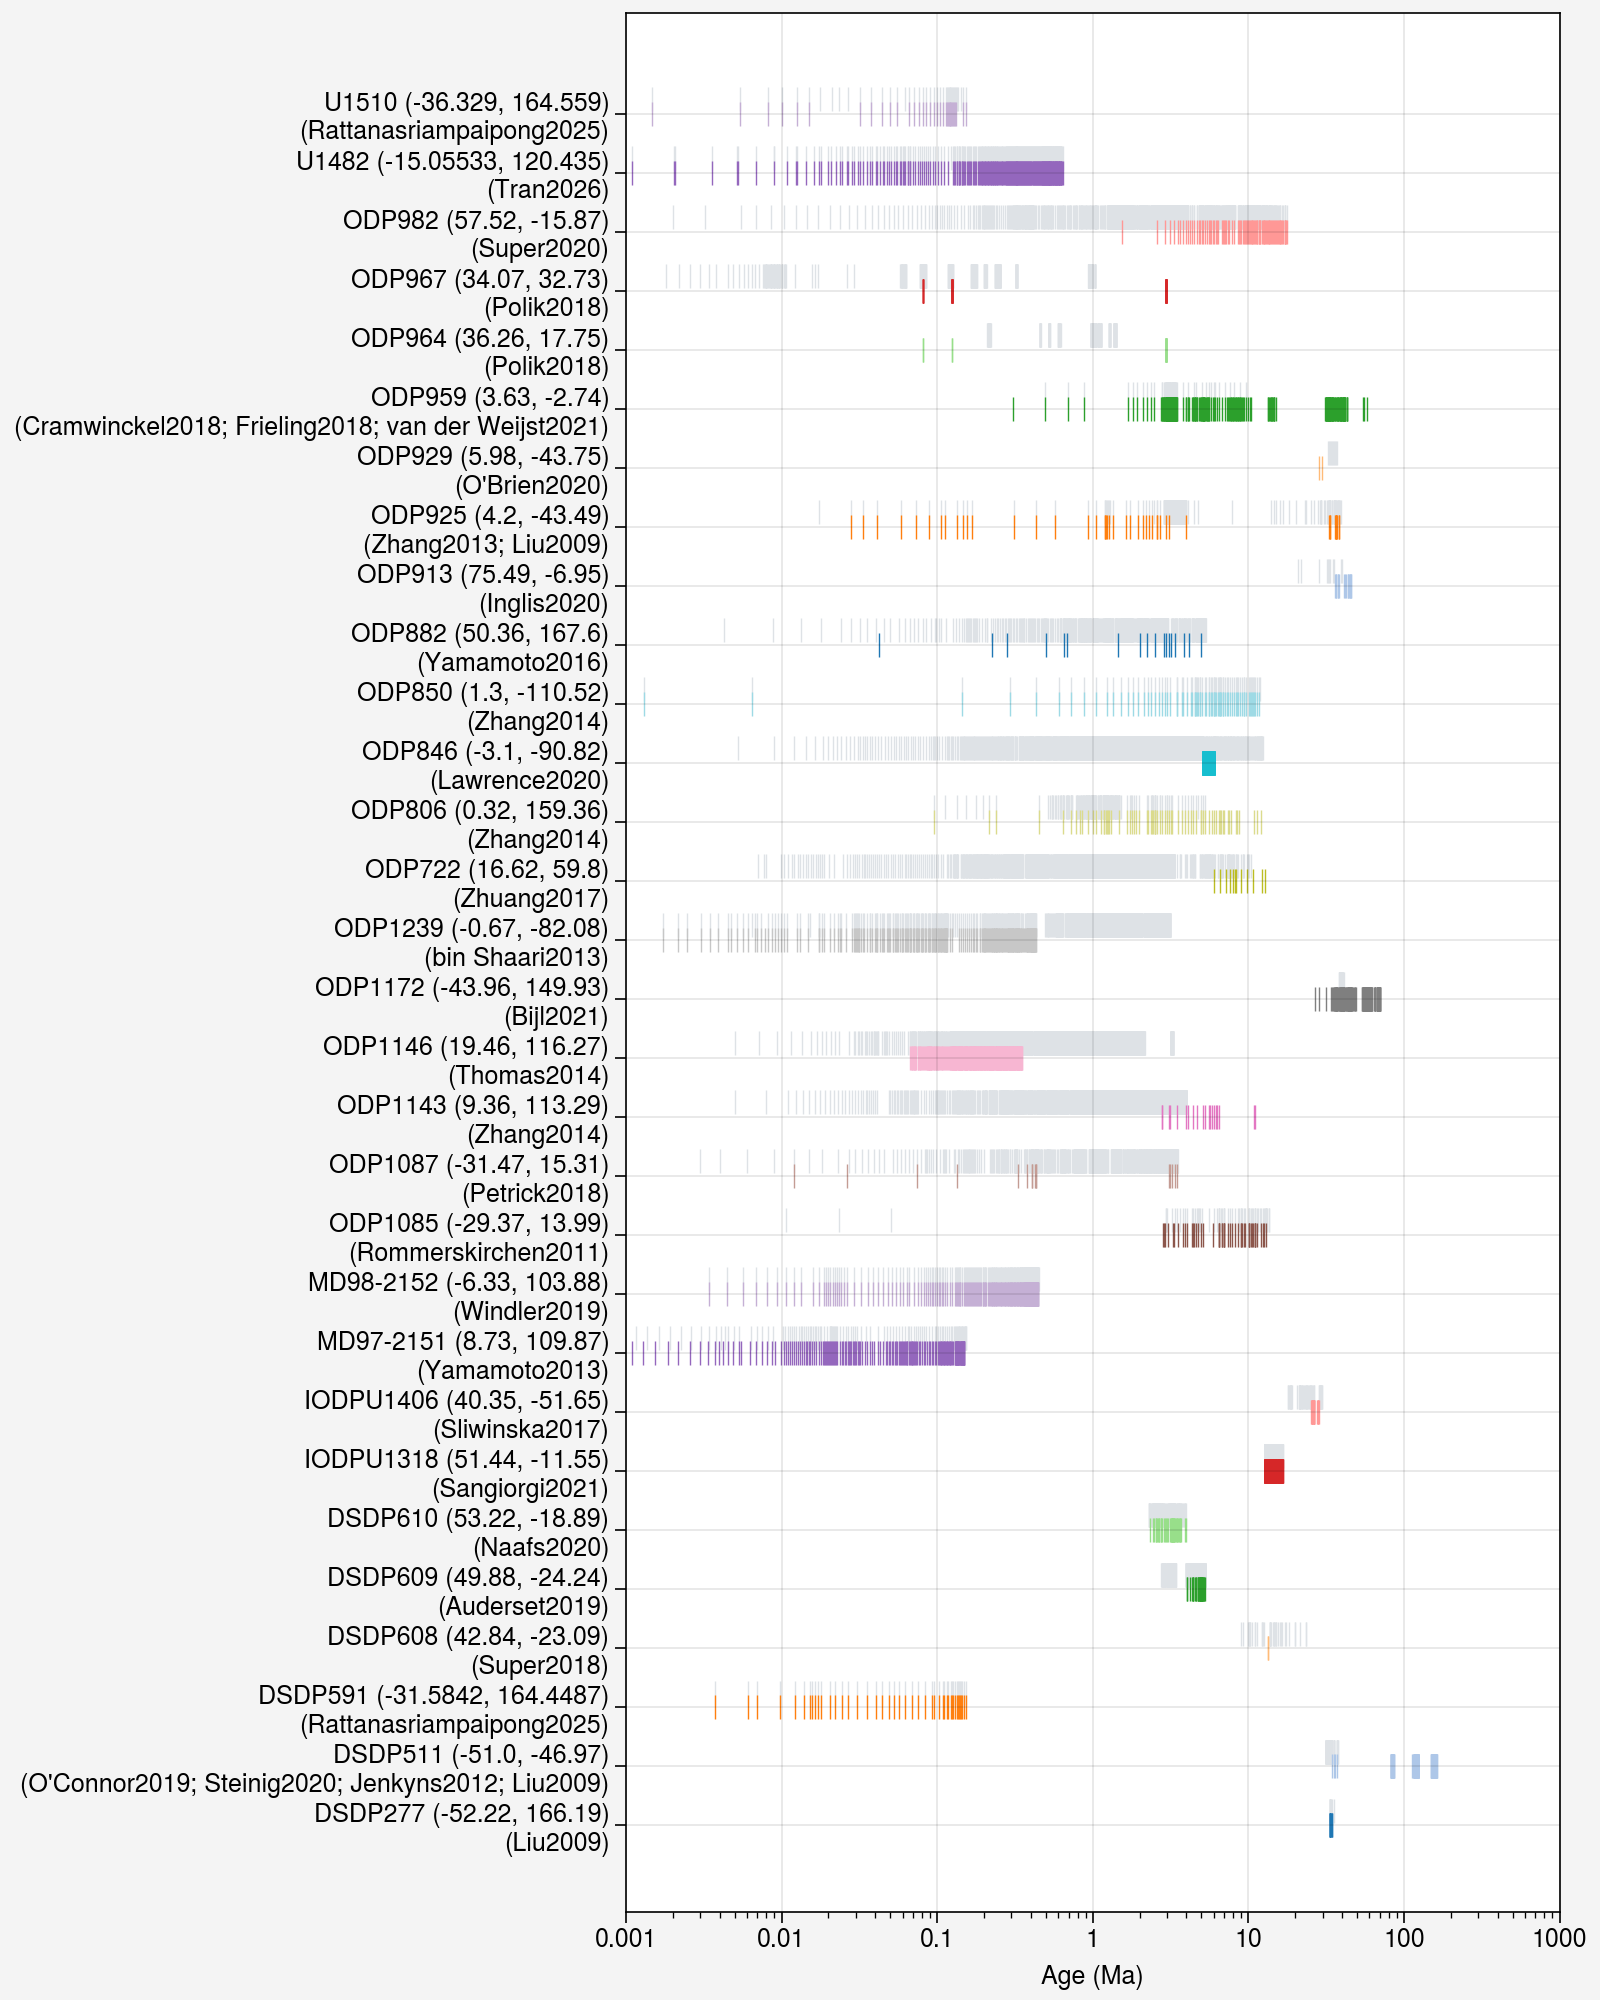

In [360]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[(
    (PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False)
    &((PhanTEX_df['scaledRI_cren3'] > 0.5)&(PhanTEX_df['scaledRI_cren3'] < 0.8))
    )].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=12, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

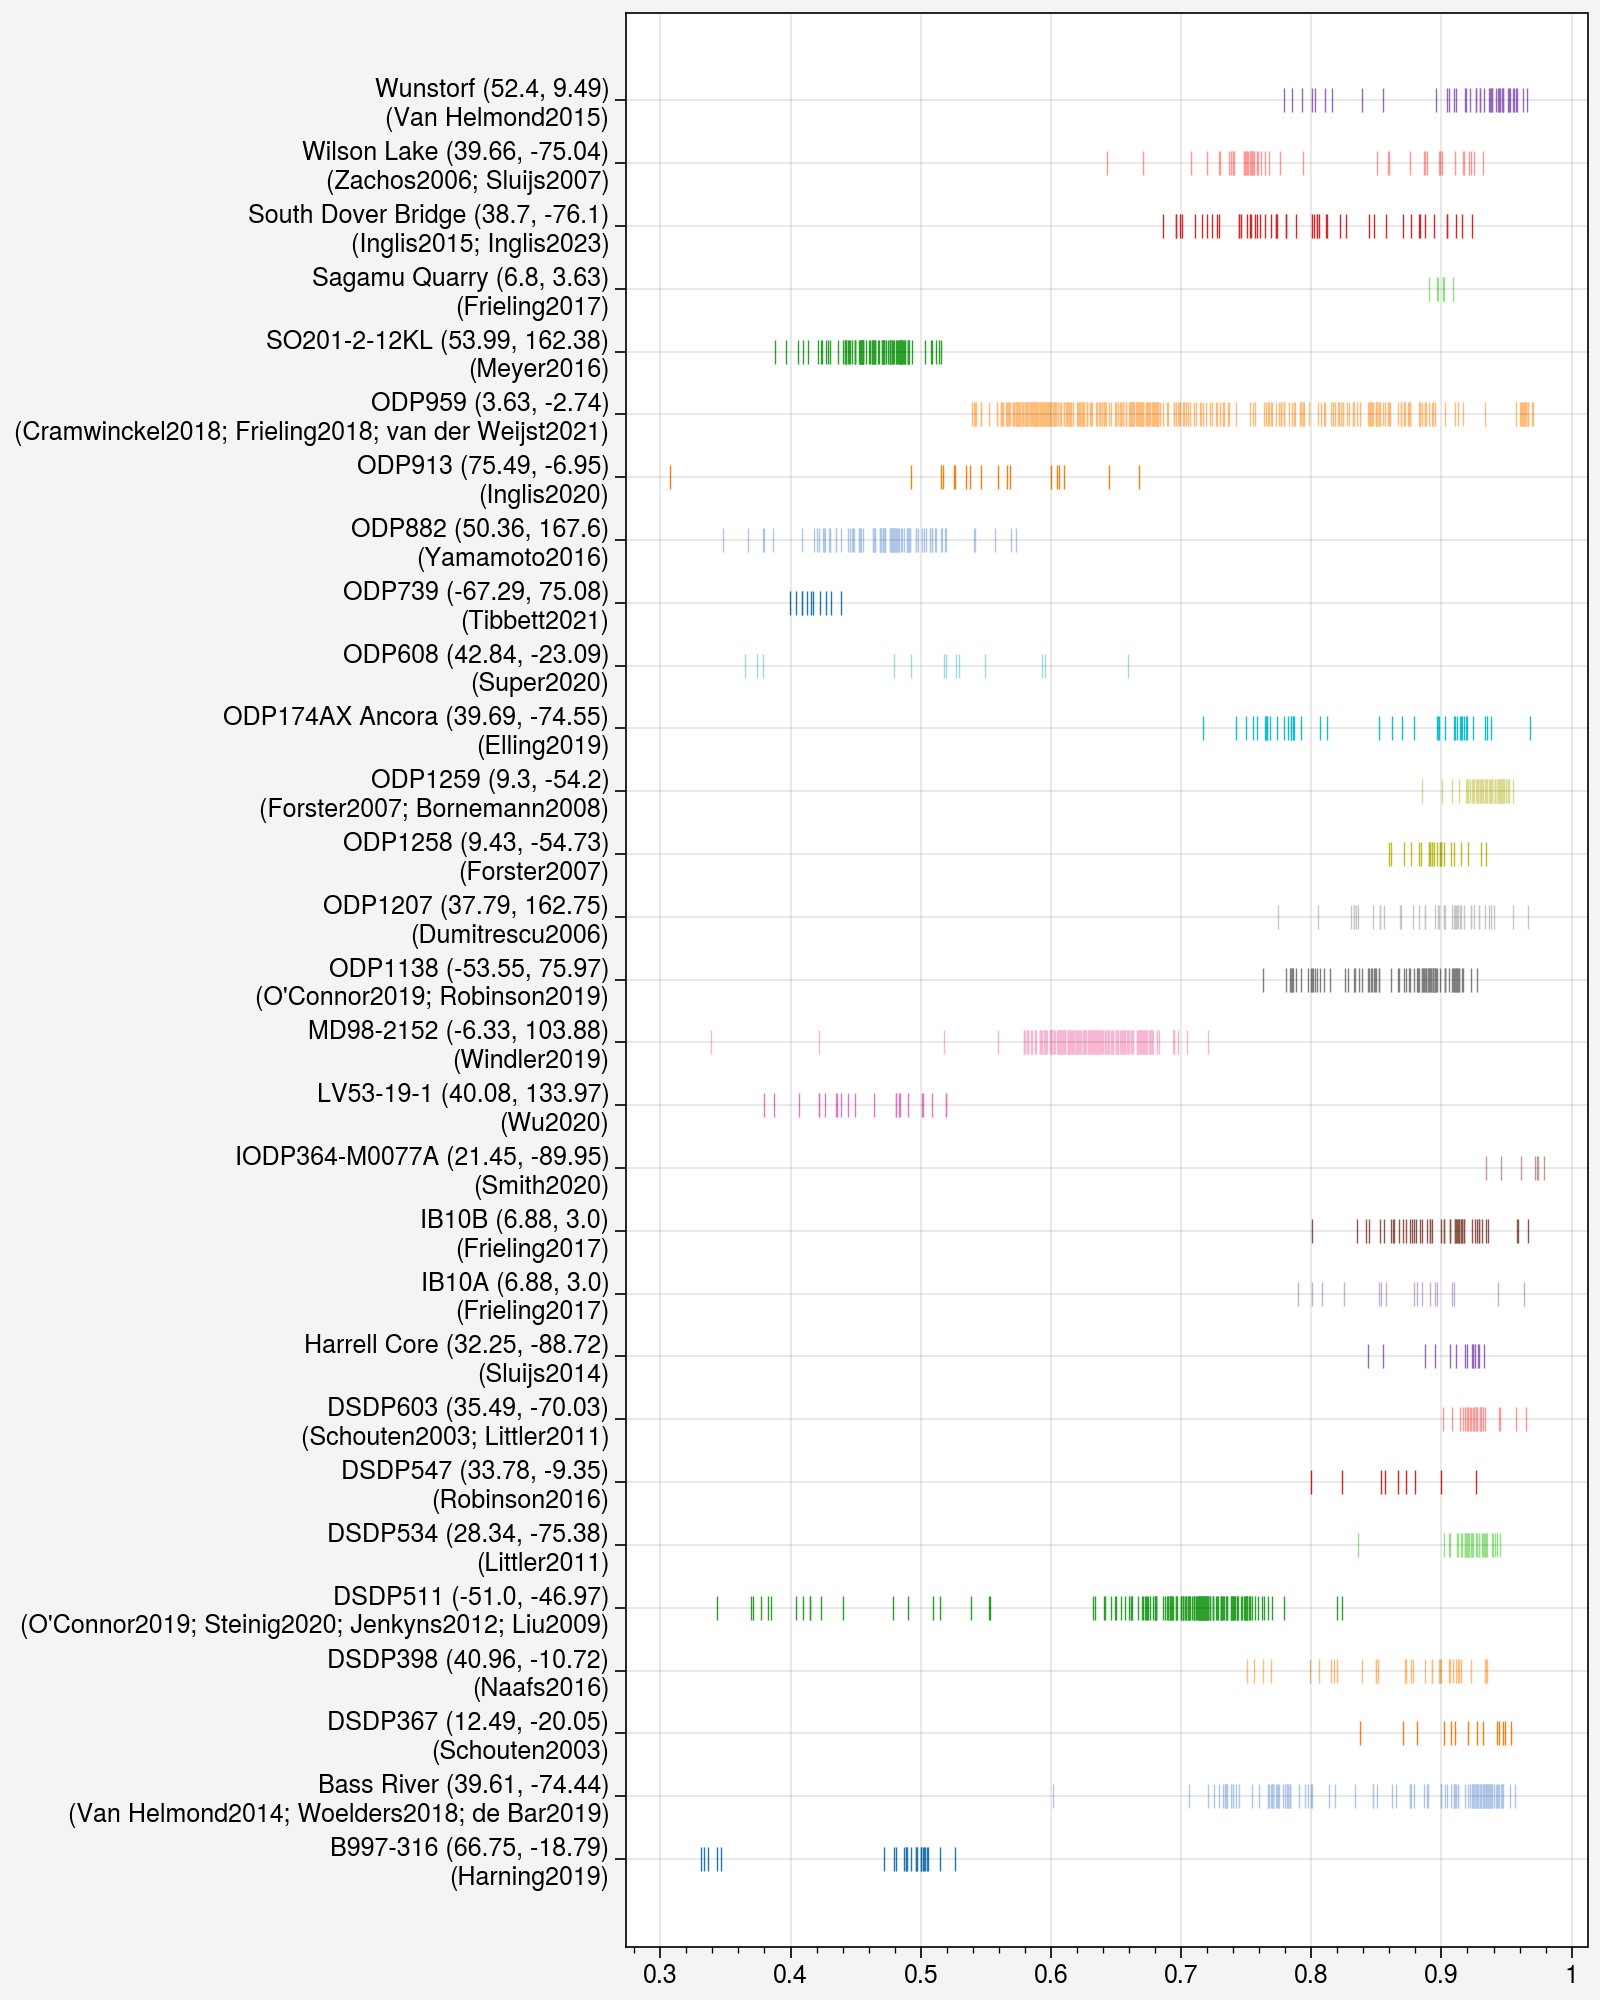

In [61]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    # print(f"Site: {group_name}")
    if not group_data.empty:
        if group_data['scaledRI_cren3'].min() < 0.4 or group_data['scaledRI_cren3'].max() > 0.9:
            plot_age = group_data['scaledRI_cren3'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['scaledRI_cren3'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=12, ha='left', va='center', color='black')
        
        
            jj += 1
                
        
ax.format(
    # xscale='log',
    # xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    # xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

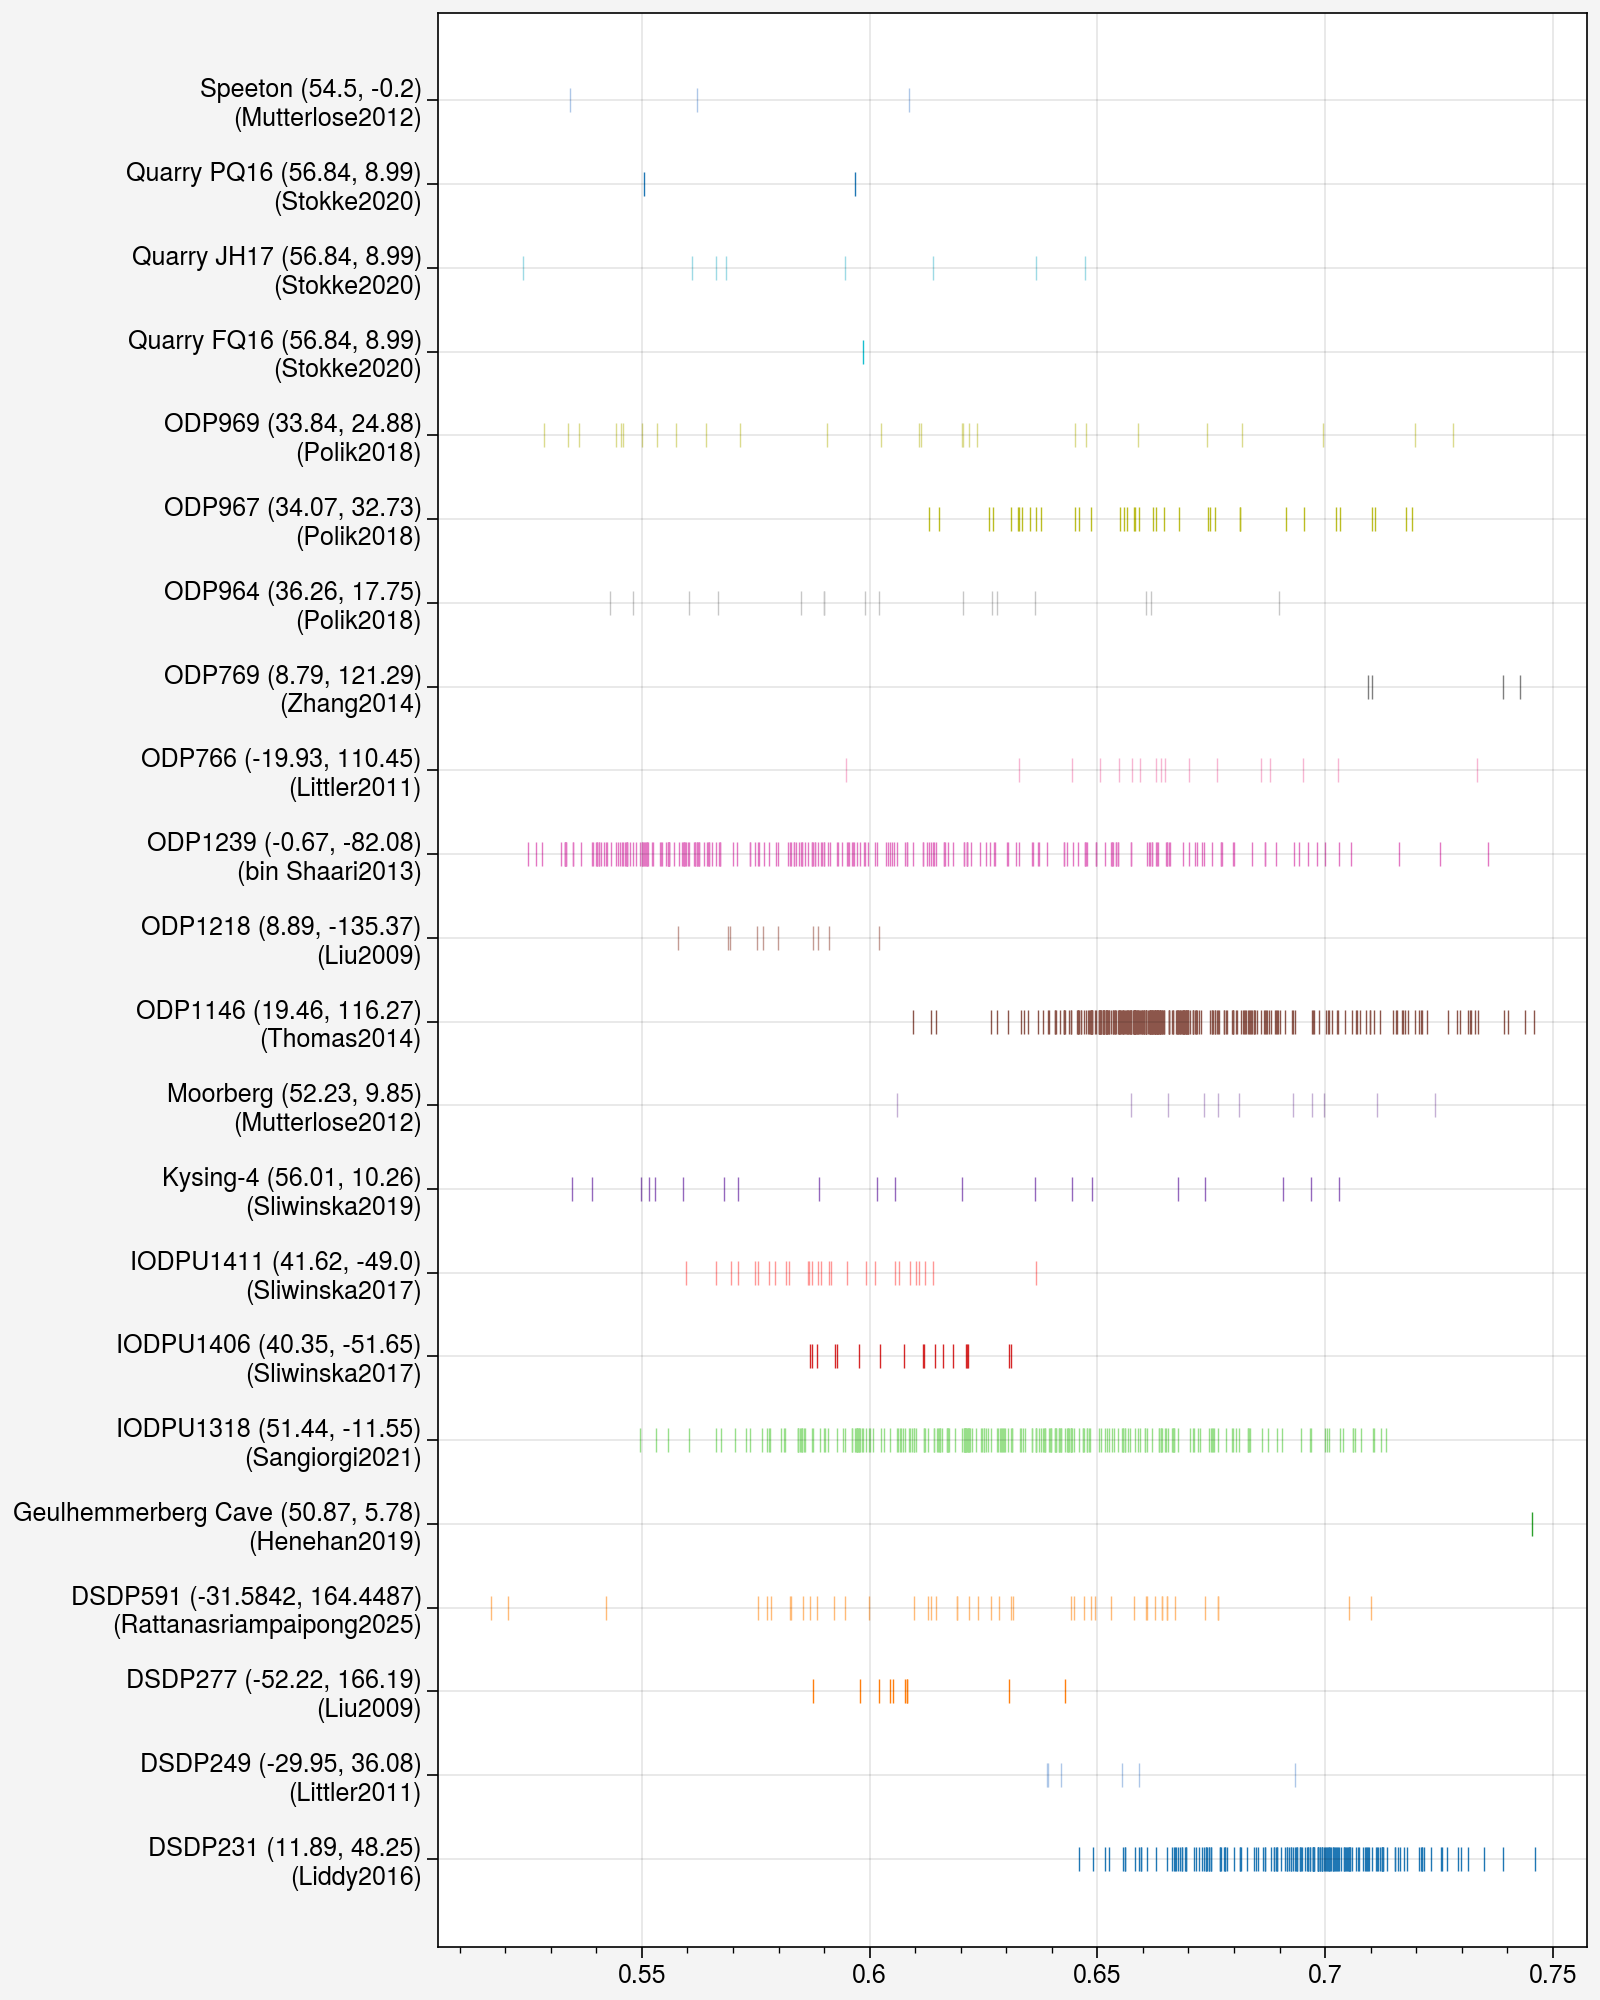

In [263]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    # print(f"Site: {group_name}")
    if not group_data.empty:
        if group_data['scaledRI_cren3'].min() > 0.5 and group_data['scaledRI_cren3'].max() < 0.75:
            plot_age = group_data['scaledRI_cren3'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['scaledRI_cren3'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=12, ha='left', va='center', color='black')
        
        
            jj += 1
                
        
ax.format(
    # xscale='log',
    # xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    # xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

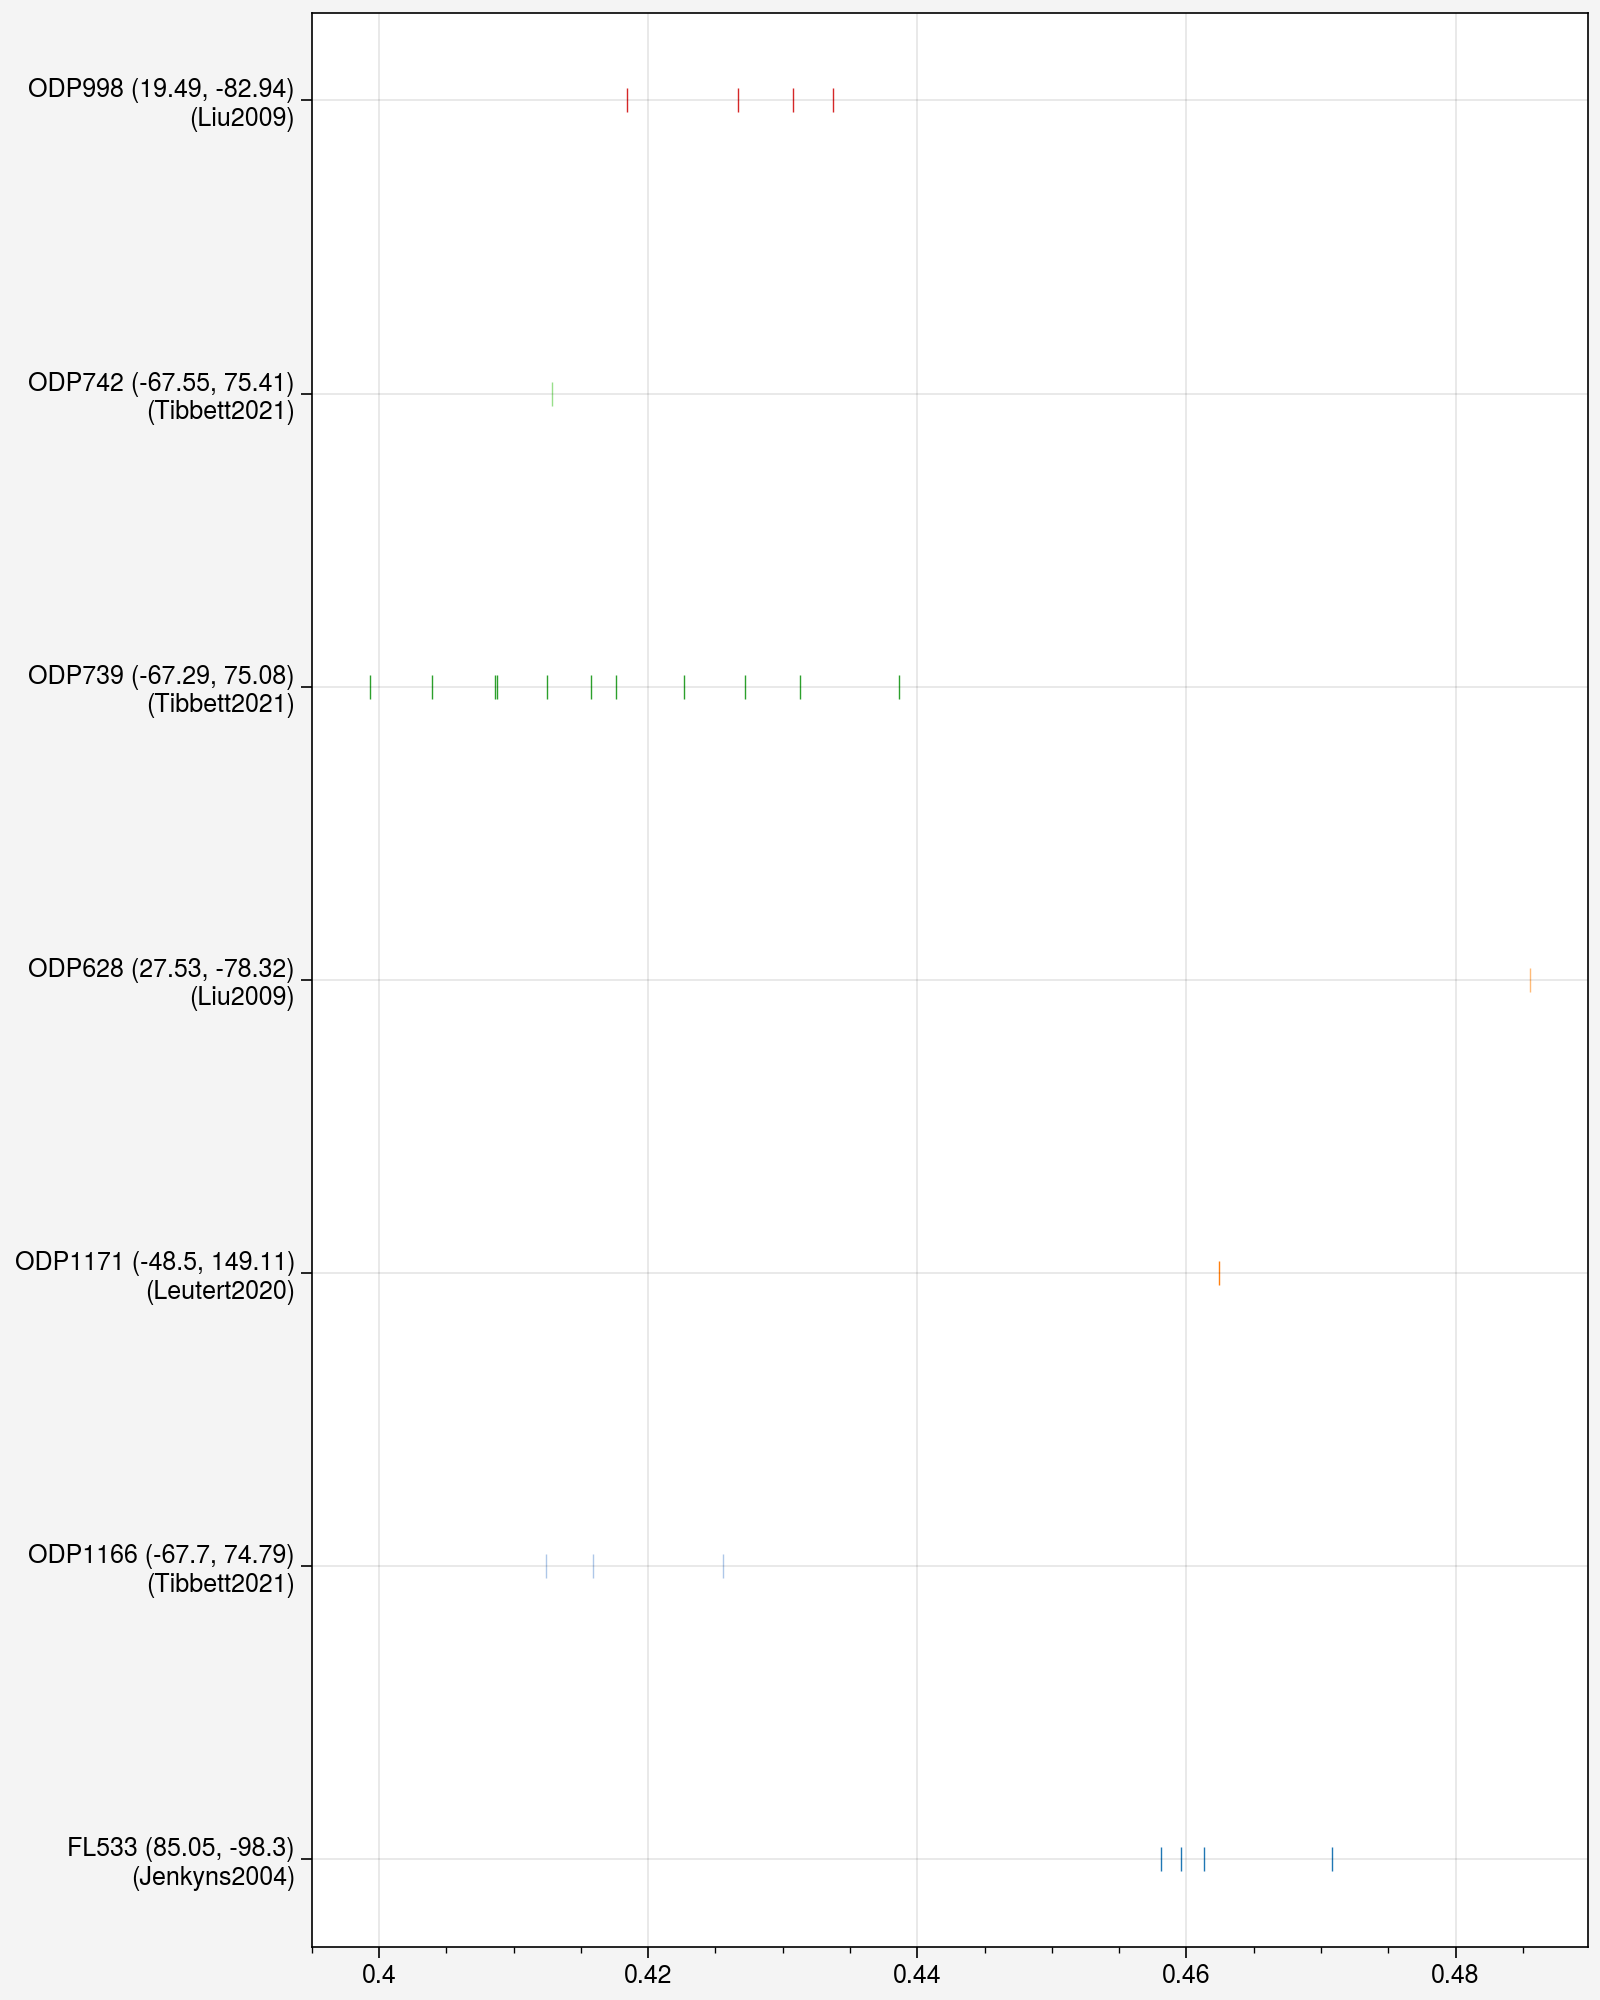

In [279]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    # print(f"Site: {group_name}")
    if not group_data.empty:
        if group_data['scaledRI_cren3'].max() < 0.5:
            plot_age = group_data['scaledRI_cren3'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['scaledRI_cren3'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=12, ha='left', va='center', color='black')
        
        
            jj += 1
                
        
ax.format(
    # xscale='log',
    # xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    # xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [471]:
# # ══════════════════════════════════════════════════════════════════════════════
# # CONFIGURATION — edit here only
# # ══════════════════════════════════════════════════════════════════════════════

# site_config = [
#     dict(
#         name   = 'ODP1259',
#         filter_col = 'TEXRI_cren3_mahalDist_low23ratio_outliers_manual',
#         prior_mu_t = 35,
#         prior_sigma_t = 10,
#         highlight     = 'median',     # idxmax of scaledRI_cren3,
#         texas_temptype = 'SST',
#         bayspar_temptype = 'sst'
#     ),
#     dict(
#         name   = 'MD98-2152',
#         filter_col = 'TEXRI_cren3_mahalDist_low23ratio_outliers_manual',
#         prior_mu_t = 20,
#         prior_sigma_t = 10,
#         highlight     = 'median',     # idxmax of scaledRI_cren3,
#         texas_temptype = 'thermoT',
#         bayspar_temptype = 'subt'  
         
#     ),
#     dict(
#         name   = 'ODP739',
#         filter_col = 'TEXRI_cren3_mahalDist_low23ratio_outliers_manual',
#         prior_mu_t = 10,
#         prior_sigma_t = 10,
#         highlight     = 'median',     # idxmax of scaledRI_cren3,
#         texas_temptype = 'SST',
#         bayspar_temptype = 'sst'   
#     ),
#     # add more sites here
# ]



# def _resolve_highlight_idx(df_plot, highlight):
#     """Resolve highlight strategy to a positional integer index into df_plot."""
#     col = df_plot['scaledRI_cren3']
#     if highlight == 'max':
#         return col.idxmax()
#     elif highlight == 'min':
#         return col.idxmin()
#     elif highlight == 'median':
#         # nearest observation to the median value
#         return (col - col.median()).abs().idxmin()
#     elif isinstance(highlight, int):
#         if not (0 <= highlight < len(df_plot)):
#             raise ValueError(
#                 f"highlight={highlight} out of range for df_plot of length {len(df_plot)}"
#             )
#         return highlight
#     else:
#         raise ValueError(f"Unknown highlight strategy: '{highlight}'. "
#                          f"Use 'max', 'min', 'median', or an integer index.")

# def _run_bayspar(tex86_series, prior_mu, prior_sigma, temptype='sst',
#                  base_search_tol=None, max_expansions=5):
#     """
#     Run BAYSPAR with progressive search_tol widening.
#     Returns percentile array (n_obs, 3) or None if no analogs found.
#     """
#     import bayspar as bsr

#     if base_search_tol is None:
#         base_search_tol = np.std(tex86_series, ddof=1) * 2

#     search_tol = base_search_tol
#     for attempt in range(max_expansions):
#         try:
#             result = bsr.predict_seatemp_analog(
#                 tex86_series,
#                 prior_std  = prior_sigma,
#                 prior_mean = prior_mu,
#                 temptype   = temptype,
#                 search_tol = search_tol,
#             )
#             # Check ensemble is non-empty before calling percentile
#             if result.ensemble.size == 0:
#                 raise ValueError("Empty ensemble")
            
#             perc = result.percentile([16, 50, 84])   # shape (n_obs, 3)
#             print(f"  BAYSPAR search_tol={search_tol:.4f} succeeded "
#                   f"(attempt {attempt + 1})")
#             return perc

#         except (ValueError, IndexError):
#             search_tol *= 2
#             print(f"  BAYSPAR search_tol={search_tol/3:.4f} failed — "
#                   f"expanding to {search_tol:.4f}")

#     print(f"  WARNING: BAYSPAR found no analogs after {max_expansions} "
#           f"expansions. Returning NaN array.")
#     n_obs = len(tex86_series)
#     return np.full((n_obs, 3), np.nan)
# # ══════════════════════════════════════════════════════════════════════════════
# # BUILD data_list — one entry per site
# # ══════════════════════════════════════════════════════════════════════════════

# def build_data_list(PhanTEX_df, site_config, fwd_posterior_name):
#     data_list = []

#     for cfg in site_config:
#         name = cfg['name']
#         texas_temptype = cfg['texas_temptype']
#         bayspar_temptype = cfg['bayspar_temptype']
#         print(f'Processing: {name}')

#         df = (
#             PhanTEX_df[PhanTEX_df['SiteName'] == name]
#             .reset_index()
#             .copy()
#         )
#         if df.empty:
#             raise ValueError(f"No rows found for SiteName == '{name}'")

#         idx    = df[cfg['filter_col']] == False
#         idx_np = idx.values
#         df_plot = df[idx].reset_index(drop=True)
        
#         no3_ = '1.9' if texas_temptype == 'thermoT' else '1.8'
        
#         fwd_posterior_name = (
#             f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{texas_temptype}_gdgt23ratio_no3_{no3_}'
#             '_scaledRI_cren3_032326'
#         )

#         result_TEXAS = predict_T_from_proxyObs(
#             proxyObs           = df['scaledRI_cren3'][idx].reset_index(drop=True),
#             prior_mu_t         = cfg['prior_mu_t'],
#             prior_sigma_t      = cfg['prior_sigma_t'],
#             fwd_posterior_name = fwd_posterior_name,
#             predictors         = {
#                 'gdgt23ratio': df['gdgt23ratio'][idx].reset_index(drop=True)
#             },
#             site_name          = name,
#             proxy_name         = 'scaledRI_cren3',
#             temptype           = texas_temptype,
#             save_results       = True,
#         )

#         print(f"  Running BAYSPAR for {name}...")
#         base_tol = np.std(df['TEX86'], ddof=1) * 2
#         result_bsr_full = _run_bayspar(
#             df['TEX86'],
#             prior_mu        = cfg['prior_mu_t'],
#             prior_sigma     = cfg['prior_sigma_t'],
#             temptype        = bayspar_temptype,
#             base_search_tol = base_tol,
#         )
#         result_bsr = result_bsr_full[idx_np, :]

#         # ── append INSIDE the loop, BEFORE return ────────────────────────────
#         data_list.append(dict(
#             df            = df,
#             df_plot       = df_plot,
#             idx           = idx,
#             result_TEXAS  = result_TEXAS,
#             result_bsr    = result_bsr,
#             label         = name,
#             highlight_idx = _resolve_highlight_idx(df_plot, cfg['highlight']),
#         ))

#     return data_list          # ← OUTSIDE the loop


# data_list = build_data_list(PhanTEX_df, site_config, fwd_posterior_name)
# import pickle

# # Save
# with open("data_list_extreme_example.pkl", "wb") as f:
#     pickle.dump(data_list, f, protocol=pickle.HIGHEST_PROTOCOL)

# Load
with open("data_list_extreme_example.pkl", "rb") as f:
    data_list = pickle.load(f)

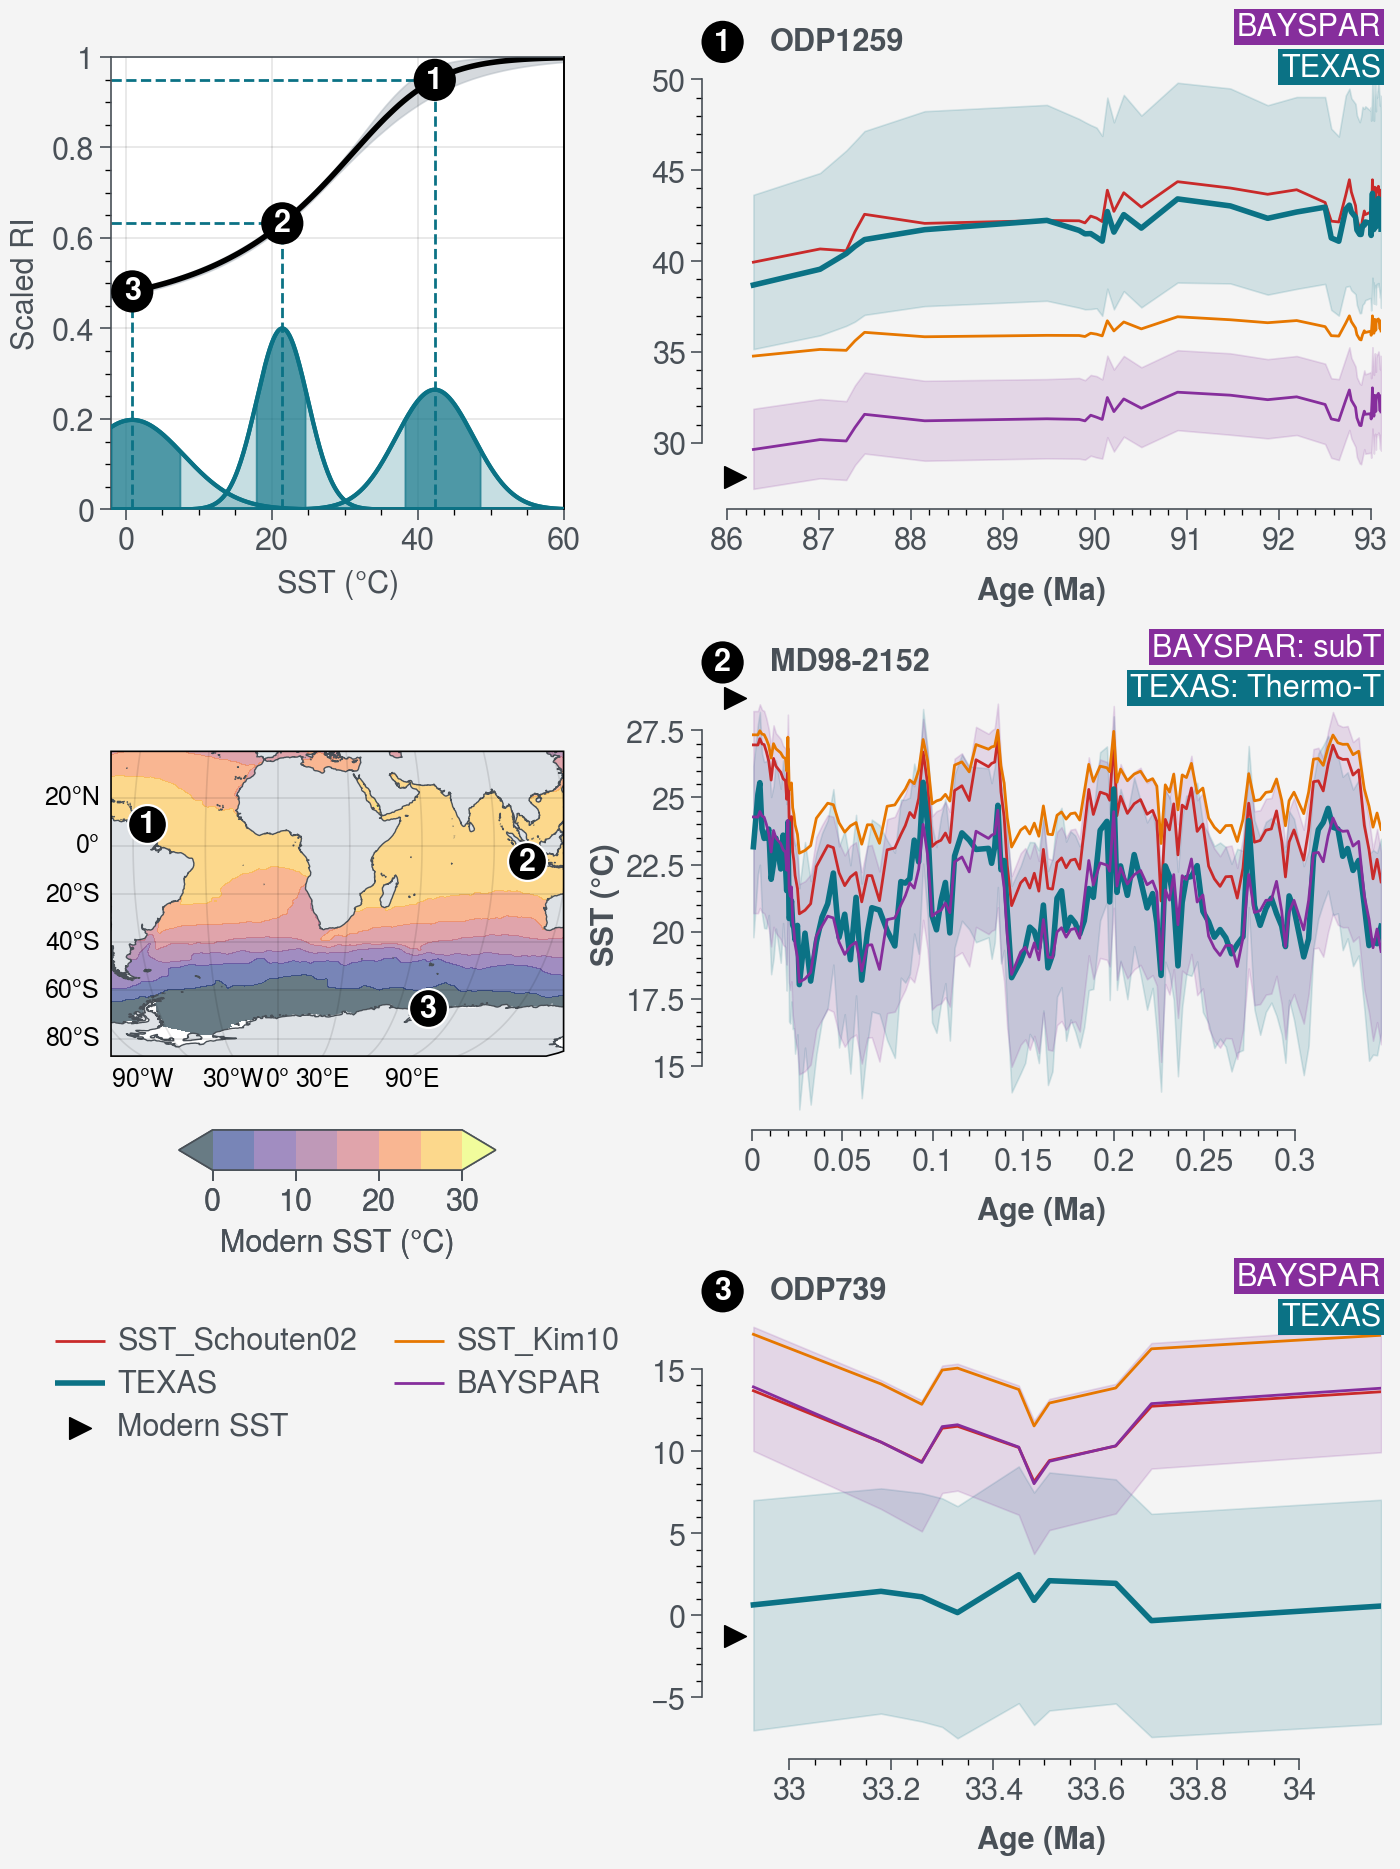

In [472]:
from scipy import stats
from proplot.axes import GeoAxes, CartesianAxes
import cartopy.feature as cfeature

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit here only
# ══════════════════════════════════════════════════════════════════════════════

features = ['SST_Schouten02', 'SST_Kim10']

model_colors = {
    'TEXAS':         'cyan9',
    'SST_Schouten02':'red9',
    'SST_Kim10':     'yellow9',
    'BAYSPAR':       'grape9',
}

model_labels = {
    'TEXAS':          'TEXAS',
    'SST_Schouten02': 'Schouten et al. 2002',
    'SST_Kim10':      r'TEX$^{H}_{86}$',
    'BAYSPAR':        'BAYSPAR',
}

published_config = {
    # 'SiteName': [
    #     dict(df=df, x='Age', y='SST', band=('p16','p84'),
    #          color='blue9', lw=1.2, ls='-', label='Published'),
    # ],
}

axis_config = {
    'MD98-2152': dict(
        # xlim=(...), ylim=(...), yticks=..., 
        plot_filter=[('TEX86','>',0.5), ('Age', '<', 0.35)],
        annot_labels={
            'TEXAS':  'TEXAS: Thermo-T',
            'BAYSPAR': 'BAYSPAR: subT',
        }
        )
}

ordered_sites = [site['label'] for site in data_list]   # edit to reorder

map_rows = 1    # how many timeseries rows the map spans (1 or 2)

# ══════════════════════════════════════════════════════════════════════════════
# REORDER + PATCH AXIS CONFIG
# ══════════════════════════════════════════════════════════════════════════════

site_lookup = {site['label']: site for site in data_list}
data_list   = [site_lookup[name] for name in ordered_sites if name in site_lookup]
missing     = [name for name in ordered_sites if name not in site_lookup]
if missing:
    print(f"WARNING: sites not found and skipped: {missing}")

for site in data_list:
    cfg = axis_config.get(site['label'], {})
    site['xlim']        = cfg.get('xlim',        None)
    site['ylim']        = cfg.get('ylim',        None)
    site['yticks']      = cfg.get('yticks',      None)
    site['plot_filter'] = cfg.get('plot_filter', None)
    site['annot_labels'] = cfg.get('annot_labels', {})

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _gaussian_from_percentiles(res, idx):
    mu    = res['p50'][idx]
    sigma = np.mean([
        (res['p84'][idx] - res['p16'][idx]) / (2 * stats.norm.ppf(0.84)),
        (res['p95'][idx] - res['p5'][idx])  / (2 * stats.norm.ppf(0.95)),
        (res['p99'][idx] - res['p1'][idx])  / (2 * stats.norm.ppf(0.99)),
    ])
    x_pdf = np.linspace(-2, 60, 500)
    y_pdf = stats.norm.pdf(x_pdf, mu, sigma)
    return mu, sigma, x_pdf, y_pdf

def _resolve_plot_filter(df, plot_filter):
    ops = {'<': lambda a,b: a<b, '<=': lambda a,b: a<=b,
           '>': lambda a,b: a>b, '>=': lambda a,b: a>=b,
           '==': lambda a,b: a==b, '!=': lambda a,b: a!=b}
    if plot_filter is None:
        return np.ones(len(df), dtype=bool)
    if callable(plot_filter):
        result = plot_filter(df)
        return np.asarray(result.values if hasattr(result, 'values') else result,
                          dtype=bool)
    if isinstance(plot_filter, list):
        mask = np.ones(len(df), dtype=bool)
        for condition in plot_filter:
            col, op, val = condition
            mask &= np.asarray(ops[op](df[col], val).values, dtype=bool)
        return mask
    if isinstance(plot_filter, tuple):
        col, op, val = plot_filter
        if op not in ops:
            raise ValueError(f"Unknown operator '{op}'. Use: {list(ops)}")
        return np.asarray(ops[op](df[col], val).values, dtype=bool)
    raise TypeError(f"plot_filter must be None, callable, (col, op, val) tuple, or list of tuples")

# ══════════════════════════════════════════════════════════════════════════════
# SHARED POSTERIOR
# ══════════════════════════════════════════════════════════════════════════════

sel_post_ds = load_posterior(
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3'
    f'_1.8_scaledRI_cren3_032326'
)
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples  = sel_post_ds["b_crtp"].values.flatten()
k_samples  = sel_post_ds["k_crtp"].values.flatten()
v_samples  = sel_post_ds["v_crtp"].values.flatten()

XX = np.linspace(-2, 60, 100)
all_curves = np.array([
    generalized_logistic_model_fixed_upper(
        XX, x0=t0_samples[i], b=b_samples[i], k=k_samples[i], v=v_samples[i]
    )
    for i in range(len(t0_samples))
])
median_curve = np.median(all_curves, axis=0)
ci_low       = np.percentile(all_curves,  1, axis=0)
ci_high      = np.percentile(all_curves, 99, axis=0)

# ══════════════════════════════════════════════════════════════════════════════
# LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

n_sites     = len(data_list)
map_rows    = min(map_rows, n_sites - 1)
include_map = n_sites > 1

ts_panels = list(range(3, 3 + n_sites))
array     = [[1, ts_panels[0]]]
for i in range(1, n_sites):
    left = 2 if i <= map_rows else 0
    array.append([left, ts_panels[i]])

hratios = [1] * n_sites

fig, axs = plot.subplots(
    array,
    width   = 7,
    hratios = hratios,
    wratios = [1, 1.5],
    proj    = {2: 'eck3'} if include_map else {},
    share   = 0,
)

ax_sig = axs[0]
ax_map = next((ax for ax in axs if isinstance(ax, GeoAxes)), None)
ts_axs = [ax for ax in axs
          if isinstance(ax, CartesianAxes) and ax is not ax_sig]

assert len(ts_axs) == n_sites, \
    f"Expected {n_sites} timeseries axes, got {len(ts_axs)}"

# ══════════════════════════════════════════════════════════════════════════════
# SIGMOID PANEL
# ══════════════════════════════════════════════════════════════════════════════

ax_sig.fill_between(XX, ci_low, ci_high, alpha=0.5, color='gray5', zorder=0)
ax_sig.plot(XX, median_curve, 'k-', lw=2, zorder=1)
ax_sig.format(xlim=(-2, 60), ylim=(0, 1),
              ylabel='Scaled RI', xlabel='SST ($\\degree$C)')

ax_twin = ax_sig.twinx()
ax_twin.set_yticks([])
# ax_twin.spines['right'].set_visible(False)
# ax_twin.spines['top'].set_visible(False)

site_pdfs = [_gaussian_from_percentiles(site['result_TEXAS'],
                                         site['highlight_idx'])
             for site in data_list]

pdf_ymax = max(y_pdf.max() for *_, y_pdf in site_pdfs)
ax_twin.set_ylim(0, pdf_ymax * 2.5)

c_texas = model_colors['TEXAS']

for row, (site, (mu, sigma, x_pdf, y_pdf)) in enumerate(zip(data_list, site_pdfs)):
    h_idx     = site['highlight_idx']
    sig_at_mu = np.interp(mu, XX, median_curve)
    p16       = site['result_TEXAS']['p16'][h_idx]
    p84       = site['result_TEXAS']['p84'][h_idx]

    ax_sig.plot([-2, mu], [sig_at_mu, sig_at_mu],
                color=c_texas, lw=1, ls='--', zorder=2)
    ax_sig.plot([mu, mu], [0, sig_at_mu],
                color=c_texas, lw=1, ls='--', zorder=2)
    ax_sig.text(mu, sig_at_mu, str(row + 1),
                transform=ax_sig.transData,
                fontsize=12, fontweight='bold', color='white',
                ha='center', va='center',
                bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                          edgecolor='none'))

    ax_twin.fill_between(x_pdf, 0, y_pdf,
                         alpha=0.12, color=c_texas, zorder=2,
                         label=site['label'])
    mask = (x_pdf >= p16) & (x_pdf <= p84)
    ax_twin.fill_between(x_pdf, 0, y_pdf,
                         where=mask, alpha=0.40, color=c_texas, zorder=3)
    ax_twin.plot(x_pdf, y_pdf, color=c_texas, lw=1.5, zorder=4)

# ══════════════════════════════════════════════════════════════════════════════
# MAP PANEL
# ══════════════════════════════════════════════════════════════════════════════

all_lats = [site['df']['ModLat'].iloc[0] for site in data_list]
all_lons = [site['df']['ModLon'].iloc[0] for site in data_list]
lat_min  = max(min(all_lats) - 20, -90)
lat_max  = min(max(all_lats) + 30,  90)
lon_min  = max(min(all_lons) - 15, -180)
lon_max  = min(max(all_lons) + 15,  180)

if include_map and ax_map is not None:
    ax_map.format(
        land=True, landcolor='gray3', landzorder=0, coast=False,
        latlabels=True, lonlabels=True, latlines=20, lonlines=30,
        latlim=(lat_min, lat_max), lonlim=(lon_min, lon_max),
    )
    ax_map.add_feature(cfeature.COASTLINE.with_scale('50m'),
                       linewidth=0.5, edgecolor='gray7', zorder=1)
    try:
        m = ax_map.contourf(
            T_da['lon'].values, T_da['lat'].values,
            T_da.isel(depth=0).values,
            levels=np.arange(0, 31, 5), extend='both',
            cmap='thermal', alpha=0.6, zorder=-1,
        )
        ax_map.colorbar(m, loc='b', label='Modern SST (°C)',
                        shrink=0.8, length=0.7)
    except Exception:
        pass
    for i, site in enumerate(data_list):
        lat = site['df']['ModLat'].iloc[0]
        lon = site['df']['ModLon'].iloc[0]
        ax_map.plot(lon, lat, marker='o', markersize=14,
                    c='k', mec='w', mew=0.8, zorder=5)
        ax_map.text(lon, lat - 0.3, str(i + 1),
                    fontsize=12, fontweight='bold', color='white',
                    ha='center', va='center', zorder=6,
                    transform=ccrs.PlateCarree())

# ══════════════════════════════════════════════════════════════════════════════
# TIMESERIES PANELS
# ══════════════════════════════════════════════════════════════════════════════

for row, (site, ax_ts) in enumerate(zip(data_list, ts_axs)):
    df_plot = site['df_plot']
    _texas  = site['result_TEXAS']
    _bsr    = site['result_bsr']

    # Apply plot filter
    pmask = np.asarray(_resolve_plot_filter(df_plot, site['plot_filter']),
                       dtype=bool)
    df_pl = df_plot[pmask].reset_index(drop=True)
    
    n_obs = len(df_plot)
    t_pl = {}
    for k, v in _texas.items():
        # Skip non-array entries (functions, None, scalars, etc.)
        if not isinstance(v, (np.ndarray, pd.Series)):
            t_pl[k] = v
            continue
        arr = v.values if isinstance(v, pd.Series) else v
        if arr.ndim == 1 and len(arr) == n_obs:
            t_pl[k] = arr[pmask]
        else:
            t_pl[k] = arr             # scalar or metadata — pass through unchanged
    b_pl  = _bsr[pmask, :] if not np.all(np.isnan(_bsr)) else _bsr

    # Modern SST triangle
    mod_lat  = site['df']['ModLat'].iloc[0]
    mod_lon  = site['df']['ModLon'].iloc[0]
    x_min    = df_pl['Age'].min()
    x_offset = (df_pl['Age'].max() - x_min) * 0.03
    try:
        mod_SST = float(
            T_da.isel(depth=0)
                .sel(lat=mod_lat, lon=mod_lon, method='nearest').values
        )
        ax_ts.scatter(x_min - x_offset, mod_SST,
                      marker='>', color='k', s=60, zorder=10, clip_on=False,
                      label='Modern SST' if row == 0 else '_nolegend_')
    except Exception:
        pass

    # Site badge + label
    ax_ts.text(0.03, 1., str(row + 1),
               transform=ax_ts.transAxes,
               fontsize=12, fontweight='bold', color='white',
               ha='center', va='bottom',
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                         edgecolor='none'))
    ax_ts.text(0.1, 1., site['label'],
               transform=ax_ts.transAxes,
               fontsize=12, fontweight='bold', color='k',
               ha='left', va='bottom')
    
    # Upper-right colored box annotations
    _annot_labels = site.get('annot_labels', {})
    # annot_items = [(f, model_colors[f]) for f in features]
    # annot_items.append(('TEXAS',  model_colors['TEXAS']))
    annot_items = [('TEXAS', model_colors['TEXAS'])]
    if not np.all(np.isnan(b_pl)):
        annot_items.append(('BAYSPAR', model_colors['BAYSPAR']))

    y_pos = 1.1
    for key, color in reversed(annot_items):
        label = _annot_labels.get(key, model_labels[key])   # fallback to generic
        ax_ts.text(
            1.0, y_pos, label,
            transform=ax_ts.transAxes,
            fontsize=9, ha='right', va='top', color='w',
            bbox=dict(facecolor=color, alpha=1,
                      edgecolor='none', boxstyle='square,pad=0.1'),
            clip_on=False,
        )
        y_pos -= 0.09


    # Comparator models
    for feature in features:
        ax_ts.plot(df_pl['Age'], df_pl[feature],
                   color=model_colors[feature], lw=1, label=feature)

    # TEXAS
    ax_ts.plot(df_pl['Age'], t_pl['p50'],
               color=c_texas, lw=2, label='TEXAS')
    ax_ts.fill_between(df_pl['Age'], t_pl['p16'], t_pl['p84'],
                       alpha=0.15, color=c_texas)

    # BAYSPAR
    if not np.all(np.isnan(b_pl)):
        ax_ts.plot(df_pl['Age'], b_pl[:, 1],
                   color=model_colors['BAYSPAR'], lw=1, label='BAYSPAR')
        ax_ts.fill_between(df_pl['Age'], b_pl[:, 0], b_pl[:, 2],
                           alpha=0.15, color=model_colors['BAYSPAR'])

    # Published records
    if published_config is not None and len(published_config) > 0:
        for rec in published_config.get(site['label'], []):
            pub_df = rec.get('df')
            if pub_df is None or pub_df.empty:
                continue
            pub_x = pub_df[rec['x']].values
            pub_y = pub_df[rec['y']].values
            ax_ts.plot(pub_x, pub_y,
                       color=rec['color'], lw=rec.get('lw', 1.2),
                       ls=rec.get('ls', '-'),
                       label=rec.get('label', '_nolegend_'),
                       zorder=4)
            band = rec.get('band')
            if band is not None:
                col_lo, col_hi = band
                ax_ts.fill_between(pub_x,
                                   pub_df[col_lo].values,
                                   pub_df[col_hi].values,
                                   color=rec['color'], alpha=0.15,
                                   lw=0, zorder=3)

    # Per-site axis limits
    fmt_kw = dict(ylabel='', xlabel='', grid=False, facecolor='none')
    if site['xlim']   is not None: fmt_kw['xlim']   = site['xlim']
    if site['ylim']   is not None: fmt_kw['ylim']   = site['ylim']
    if site['yticks'] is not None: fmt_kw['yticks'] = site['yticks']
    ax_ts.format(**fmt_kw)

# ══════════════════════════════════════════════════════════════════════════════
# SINGLE LEGEND
# ══════════════════════════════════════════════════════════════════════════════

seen = {}
for ax_ts in ts_axs:
    for h, l in zip(*ax_ts.get_legend_handles_labels()):
        if l not in seen and not l.startswith('_'):
            seen[l] = h

legend_ax = ax_map if (include_map and ax_map is not None) else ts_axs[-1]
legend_ax.legend(
    list(seen.values()), list(seen.keys()),
    loc='bottom', ncols=2, fontsize=8, frameon=False,
    bbox_to_anchor=(0.5,-0.5)
)

# ══════════════════════════════════════════════════════════════════════════════
# POST-LOOP SPINE FORMATTING
# ══════════════════════════════════════════════════════════════════════════════

n_ts    = len(ts_axs)
mid_idx = n_ts // 2

for i, ax_ts in enumerate(ts_axs):
    ax_ts.spines['top'].set_visible(False)
    ax_ts.spines['right'].set_visible(False)
    ax_ts.spines['left'].set_color('gray7')
    ax_ts.tick_params(axis='y', colors='gray7')

    yticks        = ax_ts.get_yticks()
    ylim          = ax_ts.get_ylim()
    visible_ticks = yticks[(yticks >= ylim[0]) & (yticks <= ylim[1])]
    if len(visible_ticks) >= 2:
        ax_ts.spines['left'].set_bounds(visible_ticks[0], visible_ticks[-1])

    ax_ts.spines['bottom'].set_color('gray7')
    ax_ts.spines['bottom'].set_position(('outward', 0))
    ax_ts.tick_params(axis='x', colors='gray7', bottom=True, labelbottom=True)

    xticks         = ax_ts.get_xticks()
    xlim           = ax_ts.get_xlim()
    visible_xticks = xticks[(xticks >= xlim[0]) & (xticks <= xlim[1])]
    if len(visible_xticks) >= 2:
        ax_ts.spines['bottom'].set_bounds(visible_xticks[0], visible_xticks[-1])

    if i == mid_idx:
        ax_ts.format(ylabel='SST (°C)',
                     ylabelsize=11, ylabelweight='bold', ylabelcolor='gray9')
        ax_ts.yaxis.set_label_coords(-0.12, 0.5)
    else:
        ax_ts.format(ylabel='')

for ax in ts_axs:
    ax.text(
        0.5, -0.18, 'Age (Ma)',
        fontsize=11, fontweight='bold', color='gray9',
        ha='center', va='center',
        transform=ax.transAxes,
    )

# ══════════════════════════════════════════════════════════════════════════════
# STYLE PATCH — run independently to adjust without replotting
# ══════════════════════════════════════════════════════════════════════════════

FS = dict(tick=11, label=11, title=11, badge=11, legend=11, map_label=11)
C  = dict(spine='gray7', tick='gray7', label='gray7', title='gray7',
          cbar='gray7', geo='gray7')

for ax in fig.axes:
    is_geo = isinstance(ax, GeoAxes)
    ax.tick_params(axis='both', labelsize=FS['tick'],
                   labelcolor=C['tick'], color=C['tick'])
    ax.xaxis.label.set_fontsize(FS['label'])
    ax.xaxis.label.set_color(C['label'])
    ax.yaxis.label.set_fontsize(FS['label'])
    ax.yaxis.label.set_color(C['label'])

    if not is_geo:
        for spine in ax.spines.values():
            if spine.get_visible():
                spine.set_color(C['spine'])

    for txt in ax.texts:
        if txt.get_bbox_patch() is not None:
            txt.set_fontsize(FS['badge'])
        else:
            txt.set_fontsize(FS['title'])
            if not is_geo:
                txt.set_color(C['title'])

    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(FS['legend'])
            txt.set_color(C['label'])

    if is_geo:
        try:
            gl = ax._gridliner
            if gl is not None:
                for label_list in [gl.left_labels, gl.right_labels,
                                   gl.top_labels,  gl.bottom_labels]:
                    for txt in label_list:
                        txt.set_fontsize(FS['tick'])
                        txt.set_color(C['geo'])
        except AttributeError:
            pass

try:
    for cb in fig._colorbar_dict.values():
        cb.ax.tick_params(labelsize=FS['tick'], labelcolor=C['cbar'],
                          color=C['cbar'])
        cb.ax.xaxis.label.set_fontsize(FS['label'])
        cb.ax.xaxis.label.set_color(C['cbar'])
        cb.ax.yaxis.label.set_fontsize(FS['label'])
        cb.ax.yaxis.label.set_color(C['cbar'])
except AttributeError:
    pass

# from TEXAS.models.calibration import predict_tex86_from_sst
# methods = ['schouten02','kim2010_tex86H']
# for method in methods:
#     XX = np.linspace(-2,60,200)
#     YY = predict_tex86_from_sst(XX,method=method)
#     axs[0].plot(XX,YY)

fig.canvas.draw()